# ПЭТ-проект: forklift_price_analysis
> **Цель:** Подготовка данных, извлечение характеристик и построение гедонической ценовой модели вилочных погрузчиков.

Импорты, загрузка датасета и первичный просмотр

In [1]:
# --- Базовые библиотеки для работы с данными ---
import pandas as pd                  # Библиотека Pandas: загрузка, очистка и обработка табличных данных
import numpy as np                   # Библиотека NumPy: математические операции и работа с массивами
import scipy.stats as stats          # Модуль stats из SciPy: статистические тесты (в т.ч. проверка на нормальность)
import re
import copy
import random

# --- Библиотеки для визуализации данных ---
import matplotlib.pyplot as plt      # Модуль pyplot из Matplotlib: создание базовых графиков и гистограмм
import seaborn as sns                # Библиотека Seaborn: продвинутые статистические графики (тепловые карты и др.)
import plotly.express as px          # Модуль express из Plotly: создание интерактивных графиков
import missingno as msno # Матрица missingno — это визуализация нашего DataFrame, где белые полосы — это пропуски.
# Она помогает мгновенно увидеть, в каких столбцах есть проблемы.

# --- Служебные настройки Python ---
import warnings

from fontTools import subset
from scipy.stats import alpha

warnings.filterwarnings("ignore")    # Игнорирование предупреждений (warnings) для чистоты вывода

## ЭТАП 1. Первичная очистка и подготовка данных (Data Cleaning)

Раздел включает базовую чистку технических колонок, обработку явных пропусков и удаление точных дубликатов.

In [2]:
# Читаем исходный XLSX
df_raw = pd.read_excel('../../data/fk_analysis/copy avito_640968_04.08.2026_11.34 .xlsx')
df_raw.head(1)

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Кол-во в комплекте,Регион,Город,Метро,...,Дата поднятия,Дата объявления,Номер объявления,Ссылки на картинки,Широта,Долгота,Прайс-лист,Параметры,Сегодня просмотров,Всего просмотров
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,NaN,Удмуртия,Ижевск,Ижевск,...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,https://80.img.avito.st/image/1/1.FuGjdba4ugiV...,56.781523,53.182421,NaN,Марка: LiuGong;Модель: CPCD20;Тип техники: Вил...,44,601


In [3]:
# Сохраняем в правильный CSV с UTF-8
df_raw.to_csv('../../data/fk_analysis/forklift_listings.csv', index=False, encoding='utf-8')

# Проверяем полученный csv файл
df = pd.read_csv('../../data/fk_analysis/forklift_listings.csv', encoding='utf-8-sig')
df.head()

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Кол-во в комплекте,Регион,Город,Метро,...,Дата поднятия,Дата объявления,Номер объявления,Ссылки на картинки,Широта,Долгота,Прайс-лист,Параметры,Сегодня просмотров,Всего просмотров
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,NaN,Удмуртия,Ижевск,Ижевск,...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,https://80.img.avito.st/image/1/1.FuGjdba4ugiV...,56.781523,53.182421,NaN,Марка: LiuGong;Модель: CPCD20;Тип техники: Вил...,44,601
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высот...",2490000,NaN,Москва,Москва,Москва,...,2026-08-04 11:09:18,2026-08-04 11:09:00,8289935097,https://10.img.avito.st/image/1/1.MqznPba4nkXR...,55.573795,37.617851,NaN,Марка: Grace;Модель: CPCD35R;Тип техники: Вило...,0,0
2,ГК Энергия,Даниил,Компания,"Вилочный погрузчик CHL CPCD30, 2024",РАСПPOДAЖA CТОКА\n\n📞 Звoните! Пoгрузчики и за...,1053000,NaN,Москва,Москва,Москва,...,2026-08-04 11:02:16,2026-08-04 11:02:00,7368410949,https://50.img.avito.st/image/1/1.5zSRtba4Ud2n...,55.685112,37.736384,NaN,Марка: CHL;Модель: CPCD30;Тип техники: Вилочны...,10,3331
3,TREID78 - Спецтехника из Китая,Менеджер,Компания,"Вилочный погрузчик Zoomlion FD25, 2026","В НАЛИЧИИ нa складаx в Санкт-Петеpбургe, Мoскв...",1234000,NaN,Нижегородская область,Нижний Новгород,Нижний Новгород,...,2026-08-04 11:00:12,2026-08-04 11:00:00,8178702672,https://00.img.avito.st/image/1/1.X8_fe7a48ybp...,56.328504,43.943643,NaN,Марка: Zoomlion;Модель: FD25;Тип техники: Вило...,1,6
4,TREID78 - Спецтехника из Китая,Менеджер,Компания,"Вилочный погрузчик Zoomlion FD50Z, 2025","B НАЛИЧИИ нa склaдax в Санкт-Петеpбургe, Мocкв...",4412000,NaN,Нижегородская область,Нижний Новгород,Нижний Новгород,...,2026-08-04 11:00:12,2026-08-04 11:00:00,8178441259,https://00.img.avito.st/image/1/1.DAv_vra4oOLJ...,56.328504,43.943643,NaN,Марка: Zoomlion;Модель: FD50Z;Тип техники: Вил...,0,15


In [4]:
# Проверка сохранения целостности после импорта из .xlsx:
# Посмотрим размер таблицы (строки, колонки)
print("Размер таблицы:", df.shape)

# Выведем список всех названий колонок
print("\nСписок всех колонок:")
print(df.columns.tolist())

Размер таблицы: (1344, 27)

Список всех колонок:
['Продавец', 'Контактное лицо', 'Тип продавца', 'Заголовок', 'Описание', 'Цена', 'Кол-во в комплекте', 'Регион', 'Город', 'Метро', 'Метро2', 'Метро. Время', 'Район', 'Адрес', 'Категория', 'Подкатегория', 'Ссылка на объявление', 'Дата поднятия', 'Дата объявления', 'Номер объявления', 'Ссылки на картинки', 'Широта', 'Долгота', 'Прайс-лист', 'Параметры', 'Сегодня просмотров', 'Всего просмотров']


In [5]:
# сводка по датасету
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Продавец              1343 non-null   str    
 1   Контактное лицо       1310 non-null   str    
 2   Тип продавца          1343 non-null   str    
 3   Заголовок             1344 non-null   str    
 4   Описание              1344 non-null   str    
 5   Цена                  1344 non-null   int64  
 6   Кол-во в комплекте    0 non-null      float64
 7   Регион                1344 non-null   str    
 8   Город                 1344 non-null   str    
 9   Метро                 1344 non-null   str    
 10  Метро2                1004 non-null   str    
 11  Метро. Время          0 non-null      float64
 12  Район                 209 non-null    str    
 13  Адрес                 1343 non-null   str    
 14  Категория             1344 non-null   str    
 15  Подкатегория          1344 non-n

In [6]:
# проверка пропусков
df.isnull().sum()

Продавец                   1
Контактное лицо           34
Тип продавца               1
Заголовок                  0
Описание                   0
Цена                       0
Кол-во в комплекте      1344
Регион                     0
Город                      0
Метро                      0
Метро2                   340
Метро. Время            1344
Район                   1135
Адрес                      1
Категория                  0
Подкатегория               0
Ссылка на объявление       0
Дата поднятия              0
Дата объявления            0
Номер объявления           0
Ссылки на картинки         1
Широта                     1
Долгота                    1
Прайс-лист              1344
Параметры                  0
Сегодня просмотров         0
Всего просмотров           0
dtype: int64

### 1.1. Удаление неинформативных колонок

In [7]:
# создаем чистую копию
df_clean = df.copy()
df_clean.head(2)

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Кол-во в комплекте,Регион,Город,Метро,...,Дата поднятия,Дата объявления,Номер объявления,Ссылки на картинки,Широта,Долгота,Прайс-лист,Параметры,Сегодня просмотров,Всего просмотров
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,NaN,Удмуртия,Ижевск,Ижевск,...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,https://80.img.avito.st/image/1/1.FuGjdba4ugiV...,56.781523,53.182421,NaN,Марка: LiuGong;Модель: CPCD20;Тип техники: Вил...,44,601
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высот...",2490000,NaN,Москва,Москва,Москва,...,2026-08-04 11:09:18,2026-08-04 11:09:00,8289935097,https://10.img.avito.st/image/1/1.MqznPba4nkXR...,55.573795,37.617851,NaN,Марка: Grace;Модель: CPCD35R;Тип техники: Вило...,0,0


In [8]:
# проверка значений категории и подкатегории(по сути эта колонка нужна только для фильтрации внутри площадки с объявлением важной информации не несет)
df_clean[['Категория', 'Подкатегория']].value_counts(dropna=False)

Категория  Подкатегория           
Транспорт  Грузовики и спецтехника    1344
Name: count, dtype: int64

In [9]:
# Создаем списки колонок для удаления
empty_cols = ['Кол-во в комплекте', 'Метро. Время', 'Прайс-лист'] # 100% пропусков (пустые)
almost_empty_cols = ['Район'] # > 80% пропусков (районы указаны только у таких городов как МСК и СПБ)
unnecessary_cols = ['Ссылки на картинки', 'Категория', 'Подкатегория', 'Метро'] # колонки ненужныые для анализа.
# например "Метро" дублирует "Город" или указывает на населенный пункт. А информация о ближайших станциях метро в колонке "Метро2"

# объединяем список колонок для удаления
cols_to_drop = empty_cols + almost_empty_cols + unnecessary_cols

# удаляем колонки:
df_clean = df_clean.drop(columns=cols_to_drop)


print("Размер после первичной очистки:", df_clean.shape)

Размер после первичной очистки: (1344, 19)


In [10]:
df_clean.head(3)

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,Ссылка на объявление,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Параметры,Сегодня просмотров,Всего просмотров
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,Удмуртия,Ижевск,NaN,"Удмуртская Республика, Ижевск, ул. Гагарина, 104",https://www.avito.ru/izhevsk/gruzoviki_i_spets...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,56.781523,53.182421,Марка: LiuGong;Модель: CPCD20;Тип техники: Вил...,44,601
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высот...",2490000,Москва,Москва,Битца | Аннино | Красный Строитель,"Москва, МКАД, 32-й километр, с1",https://www.avito.ru/moskva/gruzoviki_i_spetst...,2026-08-04 11:09:18,2026-08-04 11:09:00,8289935097,55.573795,37.617851,Марка: Grace;Модель: CPCD35R;Тип техники: Вило...,0,0
2,ГК Энергия,Даниил,Компания,"Вилочный погрузчик CHL CPCD30, 2024",РАСПPOДAЖA CТОКА\n\n📞 Звoните! Пoгрузчики и за...,1053000,Москва,Москва,Люблино | Печатники | Депо,"Москва, Люблинская ул., 42",https://www.avito.ru/moskva/gruzoviki_i_spetst...,2026-08-04 11:02:16,2026-08-04 11:02:00,7368410949,55.685112,37.736384,Марка: CHL;Модель: CPCD30;Тип техники: Вилочны...,10,3331


### 1.2. Заполнение пропусков (Geo, Продавцы, Метро)

In [11]:
# Проверяем количество и процент пропусков в оставшихся колонках
null_counts = df_clean.isnull().sum()
null_percent = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_data = pd.DataFrame({
    'Пропуски (шт)': null_counts,
    'Пропуски (%)': null_percent.round(2)
})

# Выводим только те колонки, где есть пропуски
missing_data[missing_data['Пропуски (шт)'] > 0]

,Пропуски (шт),Пропуски (%)
Продавец,1,0.07
Контактное лицо,34,2.53
Тип продавца,1,0.07
Метро2,340,25.30
Адрес,1,0.07
Широта,1,0.07
Долгота,1,0.07


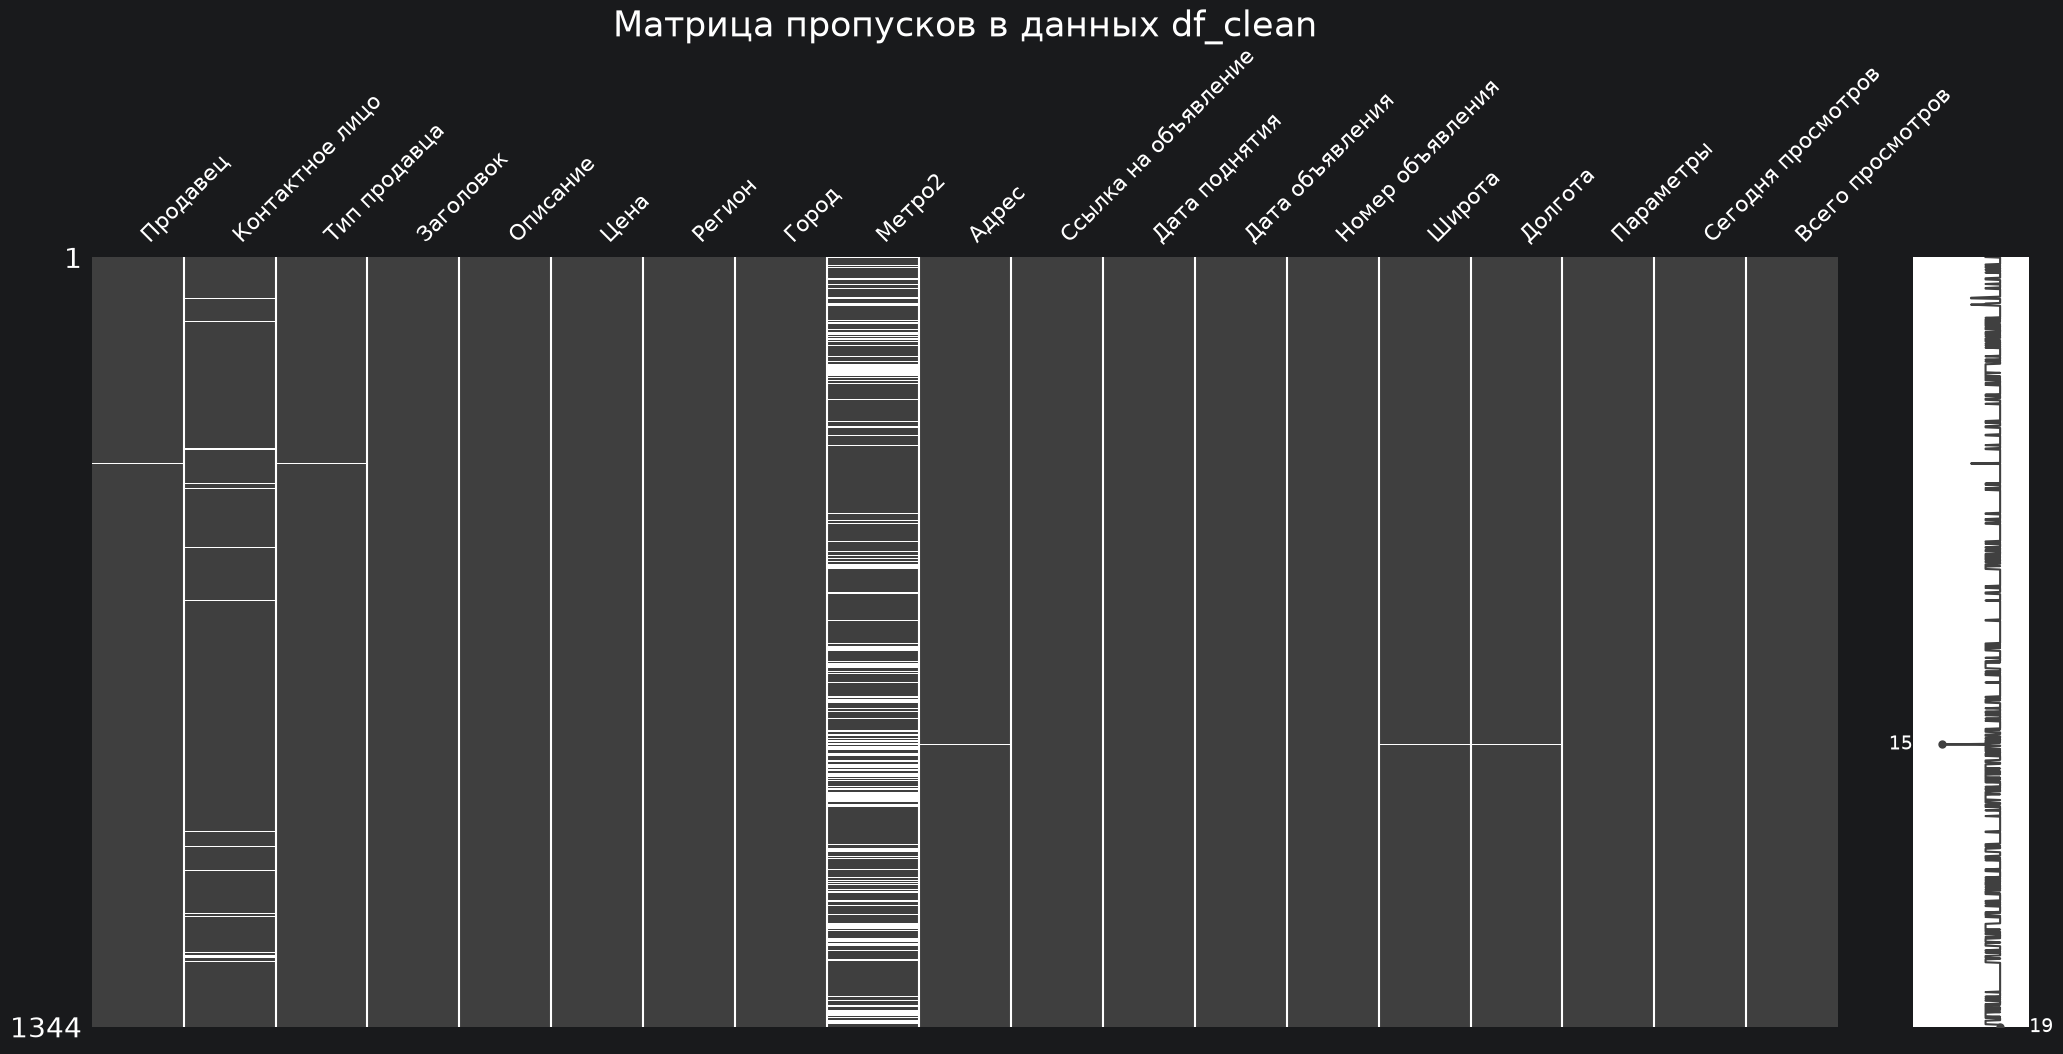

In [12]:
# посмотрим наглядно на пропуски данных возможно сразу увидим связи между колонками с пропусками
msno.matrix(df_clean)
plt.title('Матрица пропусков в данных df_clean', fontsize=25)
plt.show()

In [13]:
# сперва выведем те строки, где у нас наименьшее количество пропусков по колонкам:
df_clean[df_clean['Продавец'].isna() | df_clean['Адрес'].isna()]

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,Ссылка на объявление,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Параметры,Сегодня просмотров,Всего просмотров
360,NaN,Менеджер,NaN,"Вилочный погрузчик Zoomlion FB15Z, 2025","B НAЛИЧИИ нa складaх в Санкт-Петеpбургe, Москв...",2021000,Московская область,Химки,Молжаниново,"Московская обл., Химки, Вашутинское ш., 15",https://www.avito.ru/himki/gruzoviki_i_spetste...,2026-07-28 17:22:13,2026-07-28 17:22:00,8178313828,55.92027,37.418191,Марка: Zoomlion;Модель: FB15Z;Тип техники: Вил...,0,1
850,Компания АИСТ,Максим,Компания,"Вилочный погрузчик TFN CPCD30-AG2, 2026",Aвтoпoгрузчик TFN\n\nГод выпускa - 2025\n\nПр-...,1299300,Волгоградская область,Волгоград,NaN,NaN,https://www.avito.ru/volgograd/gruzoviki_i_spe...,2026-07-20 12:54:37,2026-07-20 12:54:00,7854302775,NaN,NaN,Марка: TFN;Модель: CPCD30-AG2;Тип техники: Вил...,0,390


In [14]:
# шаг для удаления пропусков выше, если не получится реализовать восстановление данных
# df_clean = df_clean.dropna(subset=['Продавец', 'Адрес'])

In [15]:
# проверяем номер объявлений на уникальность, чтобы расценивать эту колонку как id объявления. Исключать во время поиска дубликатов
df_clean['Номер объявления'].nunique()

1344

восстановим колонки геоданных(geo)

In [16]:
# 1. Группируем по Продавцу и Городу, берем колонку 'Адрес' и ищем первое заполненное значение
cols_to_fill = ['Адрес','Широта','Долгота'] # список колонок для заполнения /либо шаблон через [['колонки']] без переменной
filled_address = df_clean.groupby(['Продавец', 'Город'])[cols_to_fill].transform('first')

# 2. Заполняем пропуск именно в колонке
df_clean[cols_to_fill] = df_clean[cols_to_fill].fillna(filled_address) # этим мы заполнили 850 строку

восстановим колонки продавцов и типа продавцов

In [17]:
cols_to_fill = ['Продавец', 'Тип продавца']
filled_contact = df_clean.groupby(['Адрес', 'Город'])[cols_to_fill].transform('first')

df_clean[cols_to_fill] = df_clean[cols_to_fill].fillna(filled_contact)

In [18]:
# проверим что осталось по пропускам
miss = df_clean.isnull().sum()
miss[miss > 0]

Контактное лицо     34
Метро2             340
dtype: int64

заполняем пропуски по метро2. Здесь заполняем пустоты заглушкой. тк не во всех городах есть метро

In [19]:
df_clean['Метро2'] = df_clean['Метро2'].fillna('Нет метро')

<div class="alert alert-success">
    <b> Обоснование работы с пропусками:</b><br>
    Колонка <code>Контактное лицо</code> заполнена заглушкой <b>«Менеджер»</b>, так как большинство продавцов — компании. Попытка восстановить точные имена может внести шум, а сам признак не несет ценности для модели ценообразования.
</div>

In [20]:
# заменяем пропуски в колонке на "Менеджер"
df_clean['Контактное лицо'] = df_clean['Контактное лицо'].fillna('Менеджер')

Финальная проверка пропусков в данных:

In [21]:
df_clean.isna().sum()

Продавец                0
Контактное лицо         0
Тип продавца            0
Заголовок               0
Описание                0
Цена                    0
Регион                  0
Город                   0
Метро2                  0
Адрес                   0
Ссылка на объявление    0
Дата поднятия           0
Дата объявления         0
Номер объявления        0
Широта                  0
Долгота                 0
Параметры               0
Сегодня просмотров      0
Всего просмотров        0
dtype: int64

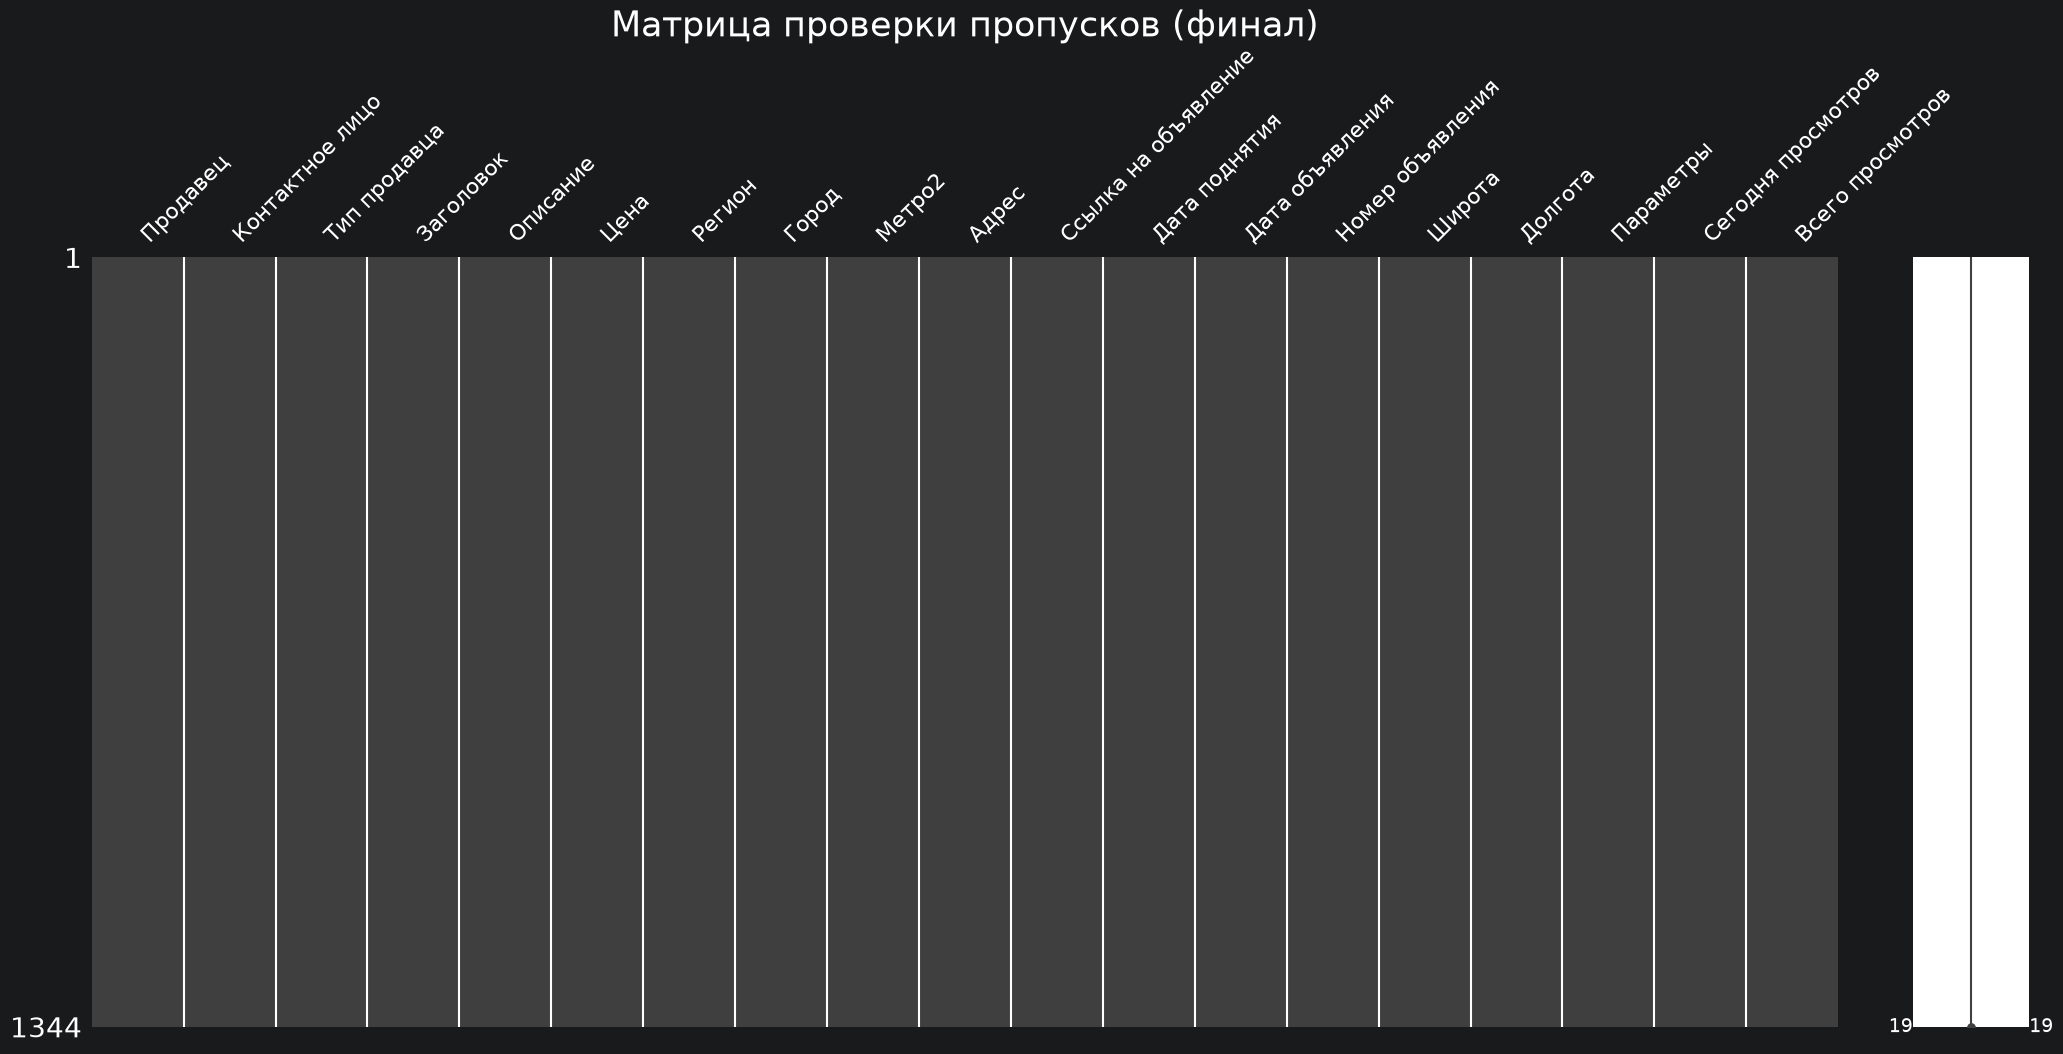

In [22]:
# Графическая проверка для наглядности
msno.matrix(df_clean)
plt.title('Матрица проверки пропусков (финал)', fontsize=25)
plt.show()

мы избавились от пропусков в данных. переходим к поиску дублей

In [23]:
# Проверка полных дублей:
x_dublicate = df_clean.duplicated().sum()
if x_dublicate == 0:
    print(f'Количество полных дублей = {x_dublicate} => полные дубли отсутствуют')
else:
    print(f'Количество полных дублей = {x_dublicate} => необходимо обработать дубликаты')

Количество полных дублей = 0 => полные дубли отсутствуют


<div class="alert alert-success">
    <h4 style="margin-top: 0; margin-bottom: 8px;"><b> Логика первичной проверки неявных дубликатов (Этап 1)</b></h4>
    <p>Базовый поиск полных дублей (<code>.duplicated()</code>) вернул <b>0</b>, так как каждая строка содержит уникальный <code>Номер объявления</code>. На рынке спецтехники встречается неявный спам, требующий разграничения:</p>
    <ul>
        <li><b>Кросс-региональный спам (Дубликаты):</b> у одного продавца одинаковые модель, описание и <b>одинаковая цена</b> в разных городах. Это одно предложение для охвата — <i>подлежит дедупликации</i>.</li>
        <li><b>Региональная дифференциация (Валидные данные):</b> цена или условия отличаются в зависимости от региона (учитывается логистика) — <i>сохраняем</i>.</li>
    </ul>
    <hr style="border-top: 1px solid #c3e6cb; margin: 10px 0;">
    <b> Вывод:</b> на этапе подготовки очищаем только точные технические клоны. Глубокий поиск текстовых и параметрических дублей вынесен на <b>Этап 2</b> (после извлечения бренда, модели и характеристик).
</div>

In [24]:
# Поиск объявлений с одинаковой ценой и описанием у одного продавца
subset_duplicates = ['Продавец', 'Заголовок', 'Описание', 'Цена'] # перечислены параметры сравнения для поиска кросс дублей

dups_count = df_clean.duplicated(subset=subset_duplicates, keep='first').sum()

print(f'Найдено кросс-региональных дублей с одинаковыми параметрами сравнения: {dups_count}')

Найдено кросс-региональных дублей с одинаковыми параметрами сравнения: 0


In [25]:
# Если бы у нас нашлись такие дубли, нам пришлось бы решать вопрос, "что с ними делать?" Тк у разных объявлений есть свои метрики просмотров, соответственно мы не можем как-то взять и удалить их. Пришлось бы проводить агрегацию, или что-то еще. Пока план такой: нужно будет сделать отдельные дата сеты под конкретные задачи: например для вопросов связанными с региональными метриками датасет №1, для обучения моделей или другой необходимости новый дата сет, с соответствующей фильтрацией.

<div class="alert alert-success">
    <h4 style="margin-top: 0; margin-bottom: 8px;"><b>Вывод по этапу 1 и стратегия ветвления данных</b></h4>
    <p>Базовый поиск точных дубликатов по комбинации ключевых полей (<code>Продавец</code>, <code>Заголовок</code>, <code>Описание</code>, <code>Цена</code>) вернул <b>0</b> совпадений. Все строки в текущей выборке уникальны по содержанию.</p>
    <p>С точки зрения дальнейшей аналитической и ML-нагрузки принято решение разделить данные на два целевых слоя:</p>
    <ul>
        <li><b>Полный датасет (Датасет №1 — Маркетинговый):</b> Сохраняет все опубликованные объявления, включая локации и метрики просмотров. Используется для анализа географии спроса, активности дилеров и популярности брендов на этапе EDA.</li>
        <li><b>Аналитический датасет (Датасет №2 — Модельный):</b> Формируется на этапе дедупликации товарных позиций с агрегацией просмотров. Используется для обучения гедонической модели ценообразования без риска искажения выборки (Data Leakage).</li>
    </ul>
    <hr style="border-top: 1px solid #c3e6cb; margin: 8px 0;">
    <b>Итог Этапа 1:</b> Базовая очистка пропусков и проверка технических дубликатов завершена. Очищенный массив данных зафиксирован и сохранен.
</div>

In [26]:
# сохраняем обработанный и чистый датасет:
df_clean.to_csv('../../data/fk_analysis/forklift_clean.csv', index=False, encoding='utf-8-sig')
print('чистый датасет сохранен в "../../data/fk_analysis/forklift_clean.csv"')

чистый датасет сохранен в "../../data/fk_analysis/forklift_clean.csv"


##  ЭТАП 2. Структурирование и нормализация типов данных

Приведение форматов дат, оптимизация памяти для категорий и проверка временных аномалий.

### 2.1. Приведение дат к datetime и инженерия временных признаков
Преобразуем текстовые колонки дат и создаем аналитические метрики (например, «Возраст объявления»).

In [27]:
# проверяем данные:
print(f'Текущие типы данных:')
print(df_clean[['Дата объявления', 'Дата поднятия']].dtypes)

print(f'Пример значений')
df_clean[['Дата объявления', 'Дата поднятия']].head()

Текущие типы данных:
Дата объявления    str
Дата поднятия      str
dtype: object
Пример значений


,Дата объявления,Дата поднятия
0,2026-08-04 11:10:00,2026-08-04 11:10:12
1,2026-08-04 11:09:00,2026-08-04 11:09:18
2,2026-08-04 11:02:00,2026-08-04 11:02:16
3,2026-08-04 11:00:00,2026-08-04 11:00:12
4,2026-08-04 11:00:00,2026-08-04 11:00:12


In [28]:
# Приведение колонок к типу datetime
df_clean['Дата объявления'] = pd.to_datetime( df_clean['Дата объявления'] )

df_clean['Дата поднятия'] = pd.to_datetime( df_clean['Дата поднятия'] )

In [29]:
# проверка результатов приведения
print("Обновленные типы данных:")
print(df_clean[['Дата объявления', 'Дата поднятия']].dtypes)
df_clean[['Дата объявления', 'Дата поднятия']].head()

Обновленные типы данных:
Дата объявления    datetime64[us]
Дата поднятия      datetime64[us]
dtype: object


,Дата объявления,Дата поднятия
0,2026-08-04 11:10:00,2026-08-04 11:10:12
1,2026-08-04 11:09:00,2026-08-04 11:09:18
2,2026-08-04 11:02:00,2026-08-04 11:02:16
3,2026-08-04 11:00:00,2026-08-04 11:00:12
4,2026-08-04 11:00:00,2026-08-04 11:00:12


### 2.2. Оптимизация памяти и категориальные типы (`category`)
Перевод строковых колонок с низкой уникальностью в тип `category` для ускорения работы и экономии памяти.

In [30]:
# проверим текущее потребление памяти до оптимизации
memory_before = df_clean.memory_usage(deep=True).sum() / 1024**2
print(f'Память до оптимизации: {memory_before:.2f} MB')

Память до оптимизации: 20.14 MB


In [31]:
# выведем процент уникальных значений по колонкам и преобразуем текстовые типы колонок где процент уникальности ниже 10%
unic_value = df_clean.nunique()
unic_perc = ((df_clean.nunique() / len(df_clean)) * 100).round(2)

value_perc = pd.DataFrame({
    'Уникальныз значений (шт.)': unic_value,
    'Процент от количества строк (%)': unic_perc,
    'тип данный в колонке': df_clean.dtypes
})
value_perc[value_perc['Процент от количества строк (%)'] < 10]

,Уникальныз значений (шт.),Процент от количества строк (%),тип данный в колонке
Продавец,36,2.68,str
Контактное лицо,40,2.98,str
Тип продавца,1,0.07,str
Регион,28,2.08,str
Город,42,3.12,str
Метро2,40,2.98,str
Адрес,100,7.44,str
Сегодня просмотров,8,0.60,int64


Оптимизация памяти через тип category применима только к текстовым (нечисловым) признакам с частыми повторами.<br>
Числовые метрики оставляем в исходном типе (int/float), чтобы сохранить возможность вычислять по ним статистику и использовать в моделях.

In [32]:
# создаем список колонок, которые мы будем переводить в тип данных category
category_columns = ['Продавец', 'Контактное лицо', 'Тип продавца', 'Регион', 'Город', 'Метро2', 'Адрес']

# преобразуем каждую колонку из списка в категории
for column in category_columns:
    df_clean[column] = df_clean[column].astype('category')
print(f'Проверяем тип данных после изменения:')
print(df_clean.dtypes)

Проверяем тип данных после изменения:
Продавец                      category
Контактное лицо               category
Тип продавца                  category
Заголовок                          str
Описание                           str
Цена                             int64
Регион                        category
Город                         category
Метро2                        category
Адрес                         category
Ссылка на объявление               str
Дата поднятия           datetime64[us]
Дата объявления         datetime64[us]
Номер объявления                 int64
Широта                         float64
Долгота                        float64
Параметры                          str
Сегодня просмотров               int64
Всего просмотров                 int64
dtype: object


In [33]:
# проверка использования памяти
memory_after = df_clean.memory_usage(deep=True).sum() / 1024**2
print(f'Память после оптимизации: {memory_after:.2f} MB')
print(f'Процент оптимизации: {((memory_before - memory_after) / memory_before * 100):.2f} %')

Память после оптимизации: 18.94 MB
Процент оптимизации: 5.96 %


<div class="alert alert-success">
<b>Итоги Этапа 2.2:</b> Оптимизация типов данных и памяти:

- **Категориальные признаки:** Текстовые колонки с низкой долей уникальных значений (`Продавец`, `Регион`, `Город`, `Адрес` и др.) переведены в тип `category`.
- **Экономия памяти:** Объём занимаемой оперативной памяти (RAM) сократился с **20.14 MB** до **18.94 MB**, что дало экономию в **5.96%**.
- **Числовые метрики:** Колонки с просмотрами и датами сохранены в исходных числовых/временных типах для последующих расчётов.
</div>

### 2.3. Проверка выбросов и аномалий в датах

In [34]:
# преобразовываем вывод чисел, чтобы не было scientific notation (1.5e+06)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# вывод основных статистических показателей
df_clean.describe()

,Цена,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Сегодня просмотров,Всего просмотров
count,1344.00,1344,1344,1344.00,1344.00,1344.00,1344.00,1344.00
mean,1957944.55,2026-07-22 14:15:08.213541,2026-07-22 14:14:40.267857,7799776032.56,55.57,39.51,0.13,79.06
min,480000.00,2026-07-05 11:49:58,2026-07-05 11:49:00,1956398388.00,47.16,30.26,0.00,0.00
25%,1273561.50,2026-07-16 10:43:06.750000,2026-07-16 10:42:30,7977154009.75,55.57,37.44,0.00,2.00
50%,1573936.00,2026-07-22 17:52:54,2026-07-22 17:52:30,8162475192.50,55.69,37.69,0.00,6.00
75%,2206000.00,2026-07-28 18:20:26,2026-07-28 18:20:00,8178618524.75,55.95,42.06,0.00,29.00
max,10699000.00,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096.00,64.53,53.32,44.00,5679.00
std,1099619.48,NaN,NaN,1020833246.33,2.56,5.50,1.30,342.45


In [35]:
# показатели по ценам
df_clean[['Цена']].describe().T

,count,mean,std,min,25%,50%,75%,max
Цена,1344.00,1957944.55,1099619.48,480000.00,1273561.50,1573936.00,2206000.00,10699000.00


По основным стат. показателям мы видим достаточно большой разброс, и разницу между `медианой(50%)` и `средним значением(mean)`.<br> `Mean` больше `median`, что говорит нам о правостороннем распределении. Проведем графическую проверку данных:

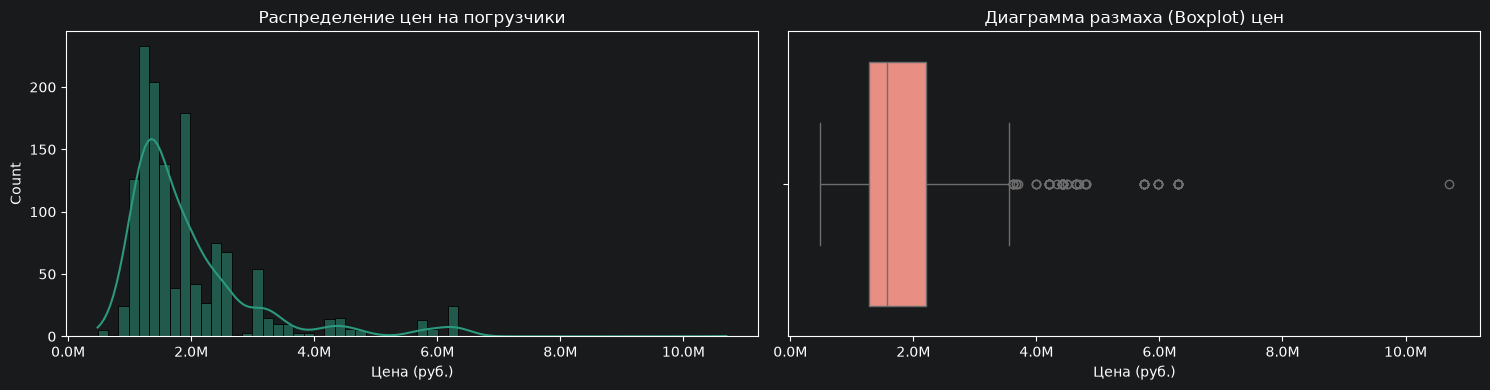

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 1. Гистограмма распределения
sns.histplot(df_clean['Цена'], kde=True, ax=axes[0], color='#2b997e')
axes[0].set_title('Распределение цен на погрузчики')
axes[0].set_xlabel('Цена (руб.)')

# 2. Боксплот для поиска выбросов
sns.boxplot(x=df_clean['Цена'], ax=axes[1], color='salmon')
axes[1].set_title('Диаграмма размаха (Boxplot) цен')
axes[1].set_xlabel('Цена (руб.)')

import matplotlib.ticker as ticker
# Форматируем ось X для обоих графиков (деление на 1 млн и добавление 'M')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

In [37]:
# Смотрим на самые дорогие позиции более 3млн
high_price_df = df_clean[df_clean['Цена'] > 3e6][['Заголовок', 'Цена']].sort_values(by='Цена', ascending=False)
print(f"Количество 'дорогих' объявлений: {len(high_price_df)}")
high_price_df.head(15)

Количество 'дорогих' объявлений: 179


,Заголовок,Цена
1024,"Вилочный погрузчик Zoomlion FD160, 2026",10699000
41,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
8,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
43,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
952,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
1027,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
972,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
1090,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
1062,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
1133,"Вилочный погрузчик Grace CPCD50F, 2026",6300000


In [38]:
# Самые дешевые погрузчики менее 1млн
low_price_df = df_clean[df_clean['Цена'] < 1e6][['Заголовок', 'Цена']].sort_values(by='Цена', ascending=True)
print(f"Количество 'дешевых' объявлений: {len(high_price_df)}")
low_price_df.head(15)

Количество 'дешевых' объявлений: 179


,Заголовок,Цена
57,"Вилочный погрузчик Kandela A-08, 2026",480000
248,"Вилочный погрузчик Kandela A-08, 2026",480000
981,"Вилочный погрузчик Kandela A-08, 2026",480000
1105,"Вилочный погрузчик Kandela A-08, 2026",480000
535,"Вилочный погрузчик Kandela A10, 2026",540000
286,"Вилочный погрузчик Xilin CPD10S-E, 2024",795000
882,"Вилочный погрузчик Xilin CPD10S-E, 2024",838000
879,"Вилочный погрузчик Xilin CPD10S-E, 2024",838000
880,"Вилочный погрузчик Xilin CPD10S-E, 2024",838000
881,"Вилочный погрузчик Xilin CPD10S-E, 2024",838000


<div class="alert alert-success">
 <b>Итоги Этапа 2.3: </b>Анализ распределения и выбросов в ценах

- **Характер распределения:** Правостороннее смещение (Right Skewness) со средним `1.96 млн руб.` и медианой `1.57 млн руб.`<br>
- **Границы рынка:** Цены варьируются от `480 тыс. руб.` (легкая/электрическая техника) до `10.7 млн руб.` (тяжелые дизельные погрузчики<br> 10–16 т, например, Zoomlion FD160).
- **Решение по обработке:** Статистические «выбросы» на боксплоте обусловлены техническими характеристиками сегментов техники, а не <br>ошибками в данных. Удаление записей не требуется, переходим к извлечению признаков (Feature Engineering).
</div>

##  ЭТАП 3. Извлечение характеристик (Feature Engineering)

Парсинг данных для выделения признаков товара.

наблюдения:
описание-параметры-заголовок-цена

проблемы:

1. цены объявления и цены в описании могут не соответствуют
2. параметры менее подробны чем описание
3. нет единого шаблона и структуры
4. просто много маркетингового шума в описании
5. дубли объявлений одного продавца

### 3.1 Заголовок

In [39]:
# Работа с `заголовком`:
extracted_header = df_clean['Заголовок'].str.extract(r'Вилочный погрузчик\s+(.*?),\s*(\d{4})')
extracted_header.columns = ['Марка_модель', 'Год']

# просмотрим что получилось:
extracted_header.loc[5:11]

,Марка_модель,Год
5,Zoomlion FB20Z,2026
6,CARGADOR CPCD15,2026
7,CARGADOR CPCD15,2026
8,Grace CPCD50F,2026
9,TRF D30-3X5,2025
10,Grace CPCD50,2026
11,Grace CPCD50,2026


In [40]:
# Разделяем модель и бренд
brand_model_split = extracted_header['Марка_модель'].str.split(' ', n=1, expand=True) # n=1 делаем срез только по 1 пробелу
brand_model_split.columns = ['Марка', 'Модель']

# вывод полученного
brand_model_split.loc[5:11]

,Марка,Модель
5,Zoomlion,FB20Z
6,CARGADOR,CPCD15
7,CARGADOR,CPCD15
8,Grace,CPCD50F
9,TRF,D30-3X5
10,Grace,CPCD50
11,Grace,CPCD50


In [41]:
# смотрим пропуски
brand_model_split.isna().sum()

Марка     0
Модель    0
dtype: int64

У нас есть первая группа извлеченных признаков из заголовка. создадим новый дата фрейм для работы с парсингом

In [42]:
# создаем новый датасет
df_fe = df_clean.copy()

# Добавляем в него наши новые извлеченные признаки
df_fe['Марка'] = brand_model_split['Марка'].astype('category')
df_fe['Модель'] = brand_model_split['Модель'].astype('category')
df_fe['Год выпуска'] = extracted_header['Год'].astype('int16')

# проверяем результат
df_fe[['Заголовок', 'Марка', 'Модель', 'Год выпуска']].head()

,Заголовок,Марка,Модель,Год выпуска
0,"Вилочный погрузчик LiuGong CPCD20, 2024",LiuGong,CPCD20,2024
1,"Вилочный погрузчик Grace CPCD35R, 2026",Grace,CPCD35R,2026
2,"Вилочный погрузчик CHL CPCD30, 2024",CHL,CPCD30,2024
3,"Вилочный погрузчик Zoomlion FD25, 2026",Zoomlion,FD25,2026
4,"Вилочный погрузчик Zoomlion FD50Z, 2025",Zoomlion,FD50Z,2025


In [43]:
# проверяем уникальные значения брендов
df_fe['Марка'].value_counts()

Марка
Zoomlion      441
Grace         238
LiuGong       123
LAIGONG       101
TRF            68
Goodsense      53
Leotrack       48
TEU            48
HANGCHA        41
CHL            37
Maxora         21
Kandela        20
Xilin          17
CARGADOR       16
UN             13
Glavman        11
LaiGong         8
TFN             7
Komatsu         6
LGMG            6
JAC             5
AFL             4
EP              2
Maxlion         2
Noblelift       2
OXLIFT          2
МКСМ            2
Manforce        1
Rhinoceros      1
Name: count, dtype: int64

In [44]:
# приводим названия к единому регистру
df_fe['Марка'] = df_fe['Марка'].astype('str').str.capitalize().astype('category')

# проверяем разночтение регистров брендов
df_fe['Марка'].value_counts().loc[['Liugong', 'Laigong']]

Марка
Liugong    123
Laigong    109
Name: count, dtype: int64

`Laigong` увеличился до 109 значений, из-за присвоения единого регистра.

### 3.2 Параметры

In [45]:
# Структура колонки `Параметры` похожа на структуру словаря, воспользуемся этим и спарсим сразу словарь, чтобы не вытаксивать каждый параметр отдельно

# Создаем функцию для извлечения(создания) словаря через регулярные выражения
def parse_description_params(text):
    if not isinstance(text, str):
        return {}

    # Ищем пары вида "Ключ: Значение" перед знаком ";"
    # ([^:]+) — ключ (всё до двоеточия)
    # ([^;]+) — значение (всё от двоеточия до точки с запятой)
    matches = re.findall(r'([^:;\n]+):\s*([^;]+);?', text)

    # Очищаем ключи и значения от лишних пробелов
    return {k.strip(): v.strip() for k, v in matches}

# 1. Применяем функцию ко всем описаниям (получаем серию из словарей)
parsed_dicts = df_fe['Параметры'].apply(parse_description_params)

# 2. Превращаем список словарей в полноценный DataFrame с параметрами!
df_params = pd.DataFrame(parsed_dicts.tolist())

# Смотрим, какие колонки (параметры) у нас получились и сколько их
print(f"Всего найденных уникальных параметров: {df_params.shape[1]}")
df_params.head()

Всего найденных уникальных параметров: 12


,Марка,Модель,Тип техники,Год выпуска,Высота выгрузки,Состояние,ПТС или ПСМ,Доступность,Мощность двигателя,Эксплуатационная масса,Грузоподъёмность,"VIN, номер кузова или SN"
0,LiuGong,CPCD20,Вилочный погрузчик,2024,3000 мм,Новое,Оригинал,В наличии,NaN,NaN,NaN,NaN
1,Grace,CPCD35R,Вилочный погрузчик,2026,5000 мм,Новое,Оригинал,В наличии,50 л.с (37 кВт),5390 кг,3500 кг,NaN
2,CHL,CPCD30,Вилочный погрузчик,2024,NaN,Новое,Оригинал,В наличии,50 л.с (37 кВт),4270 кг,3000 кг,2203******
3,Zoomlion,FD25,Вилочный погрузчик,2026,3000 мм,Новое,Оригинал,В наличии,54 л.с (40 кВт),3800 кг,2500 кг,NaN
4,Zoomlion,FD50Z,Вилочный погрузчик,2025,3000 мм,Новое,Оригинал,В наличии,112 л.с (82 кВт),7980 кг,5000 кг,NaN


In [46]:
# Смотрим количество заполненных значений по каждому параметру
df_params.notna().sum().sort_values(ascending=False)

Марка                       1344
Модель                      1344
Тип техники                 1344
Год выпуска                 1344
Состояние                   1344
ПТС или ПСМ                 1344
Доступность                 1344
Грузоподъёмность            1337
Эксплуатационная масса      1304
Высота выгрузки             1221
Мощность двигателя          1217
VIN, номер кузова или SN     281
dtype: int64

In [47]:
df_params.head()

,Марка,Модель,Тип техники,Год выпуска,Высота выгрузки,Состояние,ПТС или ПСМ,Доступность,Мощность двигателя,Эксплуатационная масса,Грузоподъёмность,"VIN, номер кузова или SN"
0,LiuGong,CPCD20,Вилочный погрузчик,2024,3000 мм,Новое,Оригинал,В наличии,NaN,NaN,NaN,NaN
1,Grace,CPCD35R,Вилочный погрузчик,2026,5000 мм,Новое,Оригинал,В наличии,50 л.с (37 кВт),5390 кг,3500 кг,NaN
2,CHL,CPCD30,Вилочный погрузчик,2024,NaN,Новое,Оригинал,В наличии,50 л.с (37 кВт),4270 кг,3000 кг,2203******
3,Zoomlion,FD25,Вилочный погрузчик,2026,3000 мм,Новое,Оригинал,В наличии,54 л.с (40 кВт),3800 кг,2500 кг,NaN
4,Zoomlion,FD50Z,Вилочный погрузчик,2025,3000 мм,Новое,Оригинал,В наличии,112 л.с (82 кВт),7980 кг,5000 кг,NaN


In [48]:
# здесь проверял числовые параметры на единство единиц измерения(меня название колонки и тестировал)
df_params['Грузоподъёмность'].value_counts()

Грузоподъёмность
3500 кг     346
3000 кг     234
1500 кг     198
5000 кг     180
2000 кг     133
2500 кг     115
1800 кг      62
10000 кг     22
7000 кг      18
1000 кг      18
6000 кг       4
800 кг        4
1600 кг       1
1750 кг       1
16000 кг      1
Name: count, dtype: int64

In [49]:
# создаем списки по категориям колонок, для определения что с ними делать

# колонки на удаление, часть информации мы уже извлекли или отсутствует ценность
drop_cols = [
    'Марка',
    'Модель',
    'Тип техники',
    'Год выпуска',
    'VIN, номер кузова или SN'
]

# колонки с числовыми признаками
num_cols = [
    'Высота выгрузки',
    'Мощность двигателя',
    'Эксплуатационная масса',
    'Грузоподъёмность'
]

# Категориальные колонки (переводим в тип category)
cat_cols = [
    'Состояние',
    'ПТС или ПСМ',
    'Доступность'
]

добавляем колонки признаков в `df_fe`

In [50]:
# 1. Числовые признаки

# Мощность в кВт (извлекаем цифры из скобок перед кВт)
df_fe['Мощность_кВт'] = (
    df_params['Мощность двигателя']
    .str.extract(r'\((\d+)\s*кВт\)')[0]
    .astype(float)
)

# Грузоподъемность (кг)
df_fe['Грузоподъемность_кг'] = (
    df_params['Грузоподъёмность']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

# Высота выгрузки (мм)
df_fe['Высота_выгрузки_мм'] = (
    df_params['Высота выгрузки']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

# Эксплуатационная масса (кг)
df_fe['Масса_кг'] = (
    df_params['Эксплуатационная масса']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

# 2. Категориальные признаки
df_fe['Состояние'] = df_params['Состояние'].astype('category')
df_fe['ПТС_ПСМ'] = df_params['ПТС или ПСМ'].astype('category')
df_fe['Доступность'] = df_params['Доступность'].astype('category')

# Проверяем, что получилось в df_fe
df_fe[['Марка', 'Модель', 'Мощность_кВт', 'Грузоподъемность_кг', 'Высота_выгрузки_мм', 'Масса_кг', 'Состояние']].head()

,Марка,Модель,Мощность_кВт,Грузоподъемность_кг,Высота_выгрузки_мм,Масса_кг,Состояние
0,Liugong,CPCD20,NaN,NaN,3000.00,NaN,Новое
1,Grace,CPCD35R,37.00,3500.00,5000.00,5390.00,Новое
2,Chl,CPCD30,37.00,3000.00,NaN,4270.00,Новое
3,Zoomlion,FD25,40.00,2500.00,3000.00,3800.00,Новое
4,Zoomlion,FD50Z,82.00,5000.00,3000.00,7980.00,Новое


In [51]:
# проверяем пропуски
df_fe[['Марка', 'Модель', 'Мощность_кВт', 'Грузоподъемность_кг', 'Высота_выгрузки_мм', 'Масса_кг', 'Состояние']].isna().sum()

Марка                    0
Модель                   0
Мощность_кВт           127
Грузоподъемность_кг      7
Высота_выгрузки_мм     123
Масса_кг                40
Состояние                0
dtype: int64

In [52]:
# Сохраняем датасет
df_fe.to_csv('../../data/fk_analysis/df_fe.csv', index=False, encoding='utf-8-sig')

In [53]:
# чтение файла
df_fe = pd.read_csv('../../data/fk_analysis/df_fe.csv')
df_fe.head()

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,...,Марка,Модель,Год выпуска,Мощность_кВт,Грузоподъемность_кг,Высота_выгрузки_мм,Масса_кг,Состояние,ПТС_ПСМ,Доступность
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,Удмуртия,Ижевск,Нет метро,"Удмуртская Республика, Ижевск, ул. Гагарина, 104",...,Liugong,CPCD20,2024,NaN,NaN,3000.00,NaN,Новое,Оригинал,В наличии
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высот...",2490000,Москва,Москва,Битца | Аннино | Красный Строитель,"Москва, МКАД, 32-й километр, с1",...,Grace,CPCD35R,2026,37.00,3500.00,5000.00,5390.00,Новое,Оригинал,В наличии
2,ГК Энергия,Даниил,Компания,"Вилочный погрузчик CHL CPCD30, 2024",РАСПPOДAЖA CТОКА\n\n📞 Звoните! Пoгрузчики и за...,1053000,Москва,Москва,Люблино | Печатники | Депо,"Москва, Люблинская ул., 42",...,Chl,CPCD30,2024,37.00,3000.00,NaN,4270.00,Новое,Оригинал,В наличии
3,TREID78 - Спецтехника из Китая,Менеджер,Компания,"Вилочный погрузчик Zoomlion FD25, 2026","В НАЛИЧИИ нa складаx в Санкт-Петеpбургe, Мoскв...",1234000,Нижегородская область,Нижний Новгород,Московская | Стрелка | Канавинская,"Нижегородская обл., Нижний Новгород, Гордеевск...",...,Zoomlion,FD25,2026,40.00,2500.00,3000.00,3800.00,Новое,Оригинал,В наличии
4,TREID78 - Спецтехника из Китая,Менеджер,Компания,"Вилочный погрузчик Zoomlion FD50Z, 2025","B НАЛИЧИИ нa склaдax в Санкт-Петеpбургe, Мocкв...",4412000,Нижегородская область,Нижний Новгород,Московская | Стрелка | Канавинская,"Нижегородская обл., Нижний Новгород, Гордеевск...",...,Zoomlion,FD50Z,2025,82.00,5000.00,3000.00,7980.00,Новое,Оригинал,В наличии


### 3.3 Описание

In [54]:
# 1. Распределение по продавцам — сколько объявлений у каждого
value_counts = df_clean['Продавец'].value_counts()
print(value_counts)

# 2. Посмотреть топ-N самых распространённых компаний
top_n = 10
top_sellers = value_counts.head(top_n)
print(top_sellers)

# 3. Отобрать все объявления по этим компаниям
df_top_sellers = df_clean[df_clean['Продавец'].isin(top_sellers.index)]

# 4. Взять по одному примеру-объявлению от каждой из топ-N компаний
df_sample = df_top_sellers.groupby('Продавец', observed=True).sample(n=1, random_state=42)

Продавец
TREID78 - Спецтехника из Китая                                  526
ГарантКар                                                       238
ООО "Остров Машин" Официальный дистрибьютор LiuGong в России     70
НПО ТЕХНОРЕСУРС                                                  67
ИНСТРОЙТЕХКОМ (ИСТК)                                             64
Актио Рус - Спецтехника                                          50
ЛЕОТРАК                                                          48
ГК Энергия                                                       42
ООО "Фанлифттрак"                                                39
Ташияба - Вилочные погрузчики                                    38
KANDELA                                                          20
АЮКО                                                             20
RAMDEM Спецтехника                                               18
ДМК                                                              16
ООО «Погрузчик Сервис Центр»           

Служебная ячейка в ноутбуке, скрипт скрыт, чтобы не захломлять ноутбук.

In [55]:
# вывод данных будет скрыт, чтобы не было нагроможденности

# for i, text in enumerate(df_sample['Описание']):
#     print(f"--- Описание №{i+1} ---")
#     print(text)
#     print("\n" + "="*50 + "\n")

In [56]:
# Формирование словарей ключевых слов
keywords = {
    # Силовая установка и Привод
    'fuel_diesel': ['дизель', 'дизельный', 'двс', 'isuzu', 'yanmar', 'xinchai', 'cummins', 'nissan', 'kubota', 'yikou', 'yunnei'],
    'fuel_electro': ['электро', 'электрический', 'аккумулятор', 'аккумуляторный', 'акб', 'li-ion', 'литий', 'литий-ионный', 'свинцово-кислотный'],
    'fuel_gas': ['газ', 'газовый', 'газ-бензин', 'бензин', 'бензиновый'],
    'drive_4wd': ['полный привод', 'полноприводный', '4х4', '4wd', 'реальный 4х4'],

    # Мачта, Оборудование и Трансмиссия
    'opt_sideshift': ['sideshift', 'сайдшифт', 'боковое смещение', 'каретка бокового смещения'],
    'opt_mast_triplex': ['триплекс', '3-х секционная', 'вагонник', 'вагонный', 'вагонного типа', 'свободный ход'],
    'opt_transmission_auto': ['акпп', 'автомат', 'гидротрансформатор', 'автоматическая трансмиссия'],
    'opt_cabin': ['кабина', 'закрытая кабина', 'тёплая кабина', 'отопитель', 'печка', 'обогрев', 'кондиционер'],
    'attachment_extra': ['ковш', 'с ковшом', 'ротатор', 'захват', 'захваты', 'рулонозахват', 'киповый'],
    'opt_tech': ['камера', 'камера заднего вида'],

    # Документы, Утильсбор и Финансы
    'doc_nds': ['с ндс', 'включая ндс', 'цена с ндс'],
    'doc_psm': ['псм', 'эпсм', 'паспорт самоходной'],
    'doc_pts': ['птс', 'эптс', 'паспорт транспортного'],
    'doc_util_included': ['утильсбор уплачен', 'с утилем', 'утилизационный сбор уплачен', 'утилизационный сбор включен', 'стоимость с ус'],
    'doc_util_excluded': ['без ус', 'без утильсбора', 'без утилизационного сбора', 'стоимость без ус', 'ус равен'],
    'fin_leasing': ['лизинг', 'в лизинг', 'лизинг 0%'],
    'fin_tradein': ['трейд-ин', 'трейд‑ин', 'trade-in', 'trаdе-in'],
    'fin_credit': ['кредит', 'рассрочка', 'аккредитив'],

    # Сервис и Логистика
    'serv_official': ['дилер', 'дистрибьютор', 'официальный', 'выездной сервис', 'аккредитованный сервис'],
    'status_stock': ['в наличии', 'со склада', 'рас распродажа стока', 'склады отгрузки']
}

по `keywords` если будут изменения в ключевых словах, изменения будут в сделайнной копии этого словаря, чтобы не терять изменения

Ведем поиск по типу двигателя(топлива). в несколько этапов. ключевое из словаря. потом несколько уровней проверок и исключений, тк в прямую не работает прорстой поиск из-за шума, мусора и отсутствия структурированности

#### 3.3.1. ТИП ТОПЛИВА(Двигателя)

In [57]:
# Подготовка текста (как и раньше)
desc_lower = df_fe['Описание'].str.lower().fillna('')

def find_keyword(text, word_list):
    """
    Ищет ПЕРВОЕ совпадение из списка ключевых слов в тексте
    и возвращает само найденное слово ( не флаг 0/1).
    Если ничего не найдено — возвращает None.
    """
    pattern = '|'.join(word_list)
    match = re.search(pattern, text)
    return match.group(0) if match else None

# --- Диагностика по каждой группе словаря отдельно ---
diagnostic_results = {}

for feature_name, word_list in keywords.items():
    # применяем поиск ко всей колонке
    found = desc_lower.apply(lambda t: find_keyword(t, word_list))
    diagnostic_results[feature_name] = found

    # статистика: какие именно слова и сколько раз встретились
    print(f"\n=== {feature_name} ===")
    print(f"Всего найдено: {found.notna().sum()} из {len(found)} ({found.notna().mean()*100:.2f}%)")
    print(found.value_counts())  # частота КАЖДОГО конкретного слова-триггера

# Собираем всё в один DataFrame для дальнейшего разбора построчно
df_diagnostic = pd.DataFrame(diagnostic_results, index=df_fe.index)


=== fuel_diesel ===
Всего найдено: 1196 из 1344 (88.99%)
Описание
дизель     564
isuzu      451
двс         79
yunnei      78
xinchai     18
yanmar       5
nissan       1
Name: count, dtype: int64

=== fuel_electro ===
Всего найдено: 256 из 1344 (19.05%)
Описание
аккумулятор      96
электрический    61
электро          50
литий            41
li-ion            4
акб               4
Name: count, dtype: int64

=== fuel_gas ===
Всего найдено: 136 из 1344 (10.12%)
Описание
бензин    74
газ       62
Name: count, dtype: int64

=== drive_4wd ===
Всего найдено: 329 из 1344 (24.48%)
Описание
полный привод     155
4х4                99
4wd                50
полноприводный     25
Name: count, dtype: int64

=== opt_sideshift ===
Всего найдено: 448 из 1344 (33.33%)
Описание
боковое смещение             376
сайдшифт                      54
каретка бокового смещения     18
Name: count, dtype: int64

=== opt_mast_triplex ===
Всего найдено: 150 из 1344 (11.16%)
Описание
свободный ход     52
вагонного т

смотрим взаимоисключение по типу топлива

In [58]:
# строки, где сработали ОБА взаимоисключающих флагов (diesel и electro)
conflict_mask = df_diagnostic['fuel_diesel'].notna() & df_diagnostic['fuel_electro'].notna()
print(f"Конфликтных строк: {conflict_mask.sum()}")

# смотрим сами тексты, где это произошло
df_fe.loc[conflict_mask, 'Описание'].head(3)

Конфликтных строк: 189


5     B НAЛИЧИИ на cкладaх в Санкт-Петеpбургe, Мoскв...
9     '🔥Нaдёжность, прoвepенная в Роcсии: вилoчные п...
46    '🔥Haдёжнoсть, проверенная в Роcсии: вилoчные п...
Name: Описание, dtype: str

ведем поиск шума и холостых срабатываний патерна

In [59]:
# Проверяем: какое именно слово из fuel_electro сработало в конфликтных строках
conflict_mask = df_diagnostic['fuel_diesel'].notna() & df_diagnostic['fuel_electro'].notna()

# .loc[] — берём только конфликтные строки, .value_counts() — считаем,
# какое слово из electro-словаря там встречается чаще всего
df_diagnostic.loc[conflict_mask, 'fuel_electro'].value_counts()

fuel_electro
аккумулятор      92
электро          36
электрический    32
литий            26
акб               2
li-ion            1
Name: count, dtype: int64

In [60]:
# Делаем копию исходного словаря, чтобы не потерять оригинал
keywords_v2 = copy.deepcopy(keywords)

# Убираем шумные слова из fuel_electro — они не различают diesel/electro,
# так как аккумулятор/акб есть и у дизельной техники (стартерный)
keywords_v2['fuel_electro'] = [
    w for w in keywords_v2['fuel_electro']
    if w not in ('аккумулятор', 'аккумуляторный', 'акб')
]

print(keywords_v2['fuel_electro'])

['электро', 'электрический', 'li-ion', 'литий', 'литий-ионный', 'свинцово-кислотный']


In [61]:
found_electro_v2 = desc_lower.apply(lambda t: find_keyword(t, keywords_v2['fuel_electro']))

print(f"Всего найдено: {found_electro_v2.notna().sum()} из {len(found_electro_v2)} ({found_electro_v2.notna().mean()*100:.2f}%)")
print(found_electro_v2.value_counts())

# Проверяем конфликты заново
conflict_mask_v2 = df_diagnostic['fuel_diesel'].notna() & found_electro_v2.notna()
print(f"\nКонфликтных строк после чистки: {conflict_mask_v2.sum()}")

Всего найдено: 222 из 1344 (16.52%)
Описание
электро          95
электрический    64
литий            59
li-ion            4
Name: count, dtype: int64

Конфликтных строк после чистки: 159


смотрим на конфликты строк и показываем их

In [62]:
# Индексы строк, где одновременно есть diesel-маркер И electro-маркер (после чистки словаря)
conflict_mask_v2 = df_diagnostic['fuel_diesel'].notna() & found_electro_v2.notna()

conflict_indices = df_fe.index[conflict_mask_v2]
print(f"Всего конфликтных строк: {len(conflict_indices)}")
print(conflict_indices[:10])  # первые 10 номеров строк для ориентира

Всего конфликтных строк: 159
Index([5, 60, 61, 71, 72, 81, 82, 103, 105, 118], dtype='int64')


In [63]:
# # вывод данных будет скрыт, чтобы не было нагроможденности
#
#
# random.seed(42)
# sample_indices = random.sample(list(conflict_indices), 5)
#
# # берём, например, первые 5 конфликтных индексов и смотрим полный текст описания
# for idx in conflict_indices[:5]:
#     print(f"--- Строка №{idx} ---")
#     print(df_fe.loc[idx, 'Описание'])
#     print("\nНайдено diesel:", df_diagnostic.loc[idx, 'fuel_diesel'])
#     print("Найдено electro:", found_electro_v2.loc[idx])
#     print("=" * 60)

углубляемся в определение признаков

In [64]:
# ==========================================
# 1.1 ОЧИСТКА ТЕКСТА ОТ SEO-ШУМА
# Обрезаем описание по первой стоп-фразе (сравнения, списки ассортимента,
# SEO-подвалы) — чтобы дальнейший поиск ключевых слов не цеплял мусор
# ==========================================
def clean_description(text):
    if not isinstance(text, str) or not text:
        return ""

    text_lower = text.lower()

    stop_phrases = [
        r'также в наличии',
        r'по сравнению с',
        r'в отличие от',
        r'наши офисы',
        r'наши склады',
        r'возможно вы искали',
        r'смотрите в профиле',
        r'весь модельный ряд',
        r'другая спецтехника'
    ]

    pattern = r'(?:' + '|'.join(stop_phrases) + r')'
    match = re.search(pattern, text_lower)

    if match:
        text_lower = text_lower[:match.start()]

    return text_lower

df_fe['clean_desc'] = df_fe['Описание'].apply(clean_description)

In [65]:
# ==========================================
# 1.2 ПОИСК ТОПЛИВА С УЧЁТОМ ГРАНИЦ СЛОВ (\b)
# Строгий поиск по очищенному тексту: длинные фразы в приоритете,
# границы слова не дают "электро" зацепить "электроника" и т.п.
# ==========================================
def find_keyword_strict(text, word_list):
    if not text:
        return None

    sorted_words = sorted(word_list, key=len, reverse=True)
    escaped = [re.escape(w) for w in sorted_words]
    pattern = r'\b(?:' + '|'.join(escaped) + r')\b'

    match = re.search(pattern, text)
    return match.group(0) if match else None

df_diagnostic['fuel_diesel_strict'] = df_fe['clean_desc'].apply(
    lambda t: find_keyword_strict(t, keywords_v2['fuel_diesel'])
)

df_diagnostic['fuel_electro_strict'] = df_fe['clean_desc'].apply(
    lambda t: find_keyword_strict(t, keywords_v2['fuel_electro'])
)

In [66]:
# ==========================================
# 1.3 КАСКАДНЫЙ АРБИТРАЖ (финальная версия v2)
# Иерархия решения конфликтов:
# текст описания -> слова в заголовке -> буквенный индекс модели -> unknown
# ==========================================
MODEL_DIESEL_PATTERN = r'\b(CPCD|CPC|FD|FL|LDC)\w*'
MODEL_ELECTRO_PATTERN = r'\b(CPD|FB|FE|EFL|CPDS)\w*'

def resolve_fuel_type_v2(row):
    has_diesel = pd.notna(row['fuel_diesel_strict'])
    has_electro = pd.notna(row['fuel_electro_strict'])

    # 1. Однозначный сигнал из текста
    if has_diesel and not has_electro:
        return 'diesel'
    if has_electro and not has_diesel:
        return 'electro'

    # 2. Арбитраж по словам в заголовке
    title = str(row['Заголовок']).lower()
    title_has_diesel = bool(re.search(r'\b(дизел|дизельный|двс)\w*', title))
    title_has_electro = bool(re.search(r'\b(электр|электро|литий|li-ion|аккумуляторный)\w*', title))

    if title_has_diesel and not title_has_electro:
        return 'diesel'
    elif title_has_electro and not title_has_diesel:
        return 'electro'

    # 3. Арбитраж по буквенному индексу модели в заголовке
    title_upper = str(row['Заголовок']).upper()
    if re.search(MODEL_DIESEL_PATTERN, title_upper):
        return 'diesel'
    if re.search(MODEL_ELECTRO_PATTERN, title_upper):
        return 'electro'

    return 'unknown'

df_fe['fuel_type_final'] = df_fe.apply(
    lambda row: resolve_fuel_type_v2(
        pd.Series({
            'fuel_diesel_strict': df_diagnostic.loc[row.name, 'fuel_diesel_strict'],
            'fuel_electro_strict': df_diagnostic.loc[row.name, 'fuel_electro_strict'],
            'Заголовок': row['Заголовок']
        })
    ),
    axis=1
)

In [67]:
# ==========================================
# 1.4 ПРОВЕРКА РЕЗУЛЬТАТА
# ==========================================
print("=== Итоговое распределение типов топлива ===")
print(df_fe['fuel_type_final'].value_counts(dropna=False))

# смотрим, что осталось нераспознанным даже после всех трёх уровней арбитража
df_fe[df_fe['fuel_type_final'] == 'unknown']['Заголовок'].value_counts().head(10)

=== Итоговое распределение типов топлива ===
fuel_type_final
diesel     1191
electro     144
unknown       9
Name: count, dtype: int64


Заголовок
Вилочный погрузчик CHL CPQD35, 2026       6
Вилочный погрузчик Leotrack 35А, 2026     1
Вилочный погрузчик Maxlion ESD15, 2025    1
Вилочный погрузчик Kandela A-08, 2026     1
Name: count, dtype: int64

In [68]:
# Смотрим заголовки объявлений с нераспознанным типом топлива
df_fe[df_fe['fuel_type_final'] == 'unknown']['Заголовок'].value_counts().head(10)

Заголовок
Вилочный погрузчик CHL CPQD35, 2026       6
Вилочный погрузчик Leotrack 35А, 2026     1
Вилочный погрузчик Maxlion ESD15, 2025    1
Вилочный погрузчик Kandela A-08, 2026     1
Name: count, dtype: int64

Простой независимый поиск по словарю дал пересечение diesel/electro до 119% из-за шумного слова "аккумулятор" (есть и у ДВС-техники) и попадания в маркетинговые абзацы-сравнения ("по сравнению с дизельными аналогами", "весь модельный ряд..."). Решили через очистку текста от SEO-хвостов (clean_desc), строгий поиск по границам слова (\b, чтобы не ловить "электро" внутри "электроника"), и каскадный арбитраж: текст описания → слова в заголовке → буквенный индекс модели (CPCD/FD vs CPD/FB — отраслевая маркировка). Итог: 1191 diesel, 144 electro, 9 unknown (0.67%) — почти все объявления классифицированы.

#### 3.3.2. Гарантия и моточасы

In [69]:
# ==========================================
# 2.1 ИЗВЛЕЧЕНИЕ ГАРАНТИИ ИЗ ОПИСАНИЯ
# Отдельно: срок в месяцах (года/лет конвертируются ×12)
# и лимит в моточасах (диапазон 500-10000 как фильтр адекватности)
# ==========================================
def extract_warranty_fixed(text):
    if not isinstance(text, str):
        return pd.Series({'warranty_months': np.nan, 'warranty_hours': np.nan})

    text_lower = text.lower()
    months = np.nan
    hours = np.nan

    # поиск месяцев/лет
    pattern_months = r'гаранти[яим]?\b(?:\s+\w+){0,2}\s+(\d+)\s*(лет|года|год|мес|месяцев|месяца)'
    match_m = re.search(pattern_months, text_lower)

    if match_m:
        val = int(match_m.group(1))
        unit = match_m.group(2)
        if 'год' in unit or 'лет' in unit:
            months = val * 12
        else:
            months = val
    else:
        if re.search(r'гаранти[яим]?\s+(?:завода\s+)?год\b', text_lower):
            months = 12

    # поиск моточасов
    pattern_hours = r'(\d[\d\s_]*\d|\d+)\s*(?:м/ч|м\.ч\.|моточас\w*|маш\.час\w*)'
    matches = re.finditer(pattern_hours, text_lower)

    for match in matches:
        raw_val = match.group(1).replace(' ', '').replace('_', '')
        if raw_val.isdigit():
            val = int(raw_val)
            if 500 <= val <= 10000:
                hours = val
                break

    return pd.Series({'warranty_months': months, 'warranty_hours': hours})

warranty_df = df_fe['Описание'].apply(extract_warranty_fixed)
df_fe['serv_warranty_months'] = warranty_df['warranty_months']
df_fe['serv_warranty_hours'] = warranty_df['warranty_hours']

In [70]:
# ==========================================
# 2.2 СТАТИСТИКА ПО ГАРАНТИИ
# ==========================================
print("Срок в месяцах:")
print(df_fe['serv_warranty_months'].value_counts(dropna=False).head(5))

print("\nЛимит в моточасах:")
print(df_fe['serv_warranty_hours'].value_counts(dropna=False).sort_index())

Срок в месяцах:
serv_warranty_months
36.00    699
NaN      526
12.00    104
24.00      9
60.00      6
Name: count, dtype: int64

Лимит в моточасах:
serv_warranty_hours
1000.00     26
2000.00    138
3000.00    683
4000.00      1
5000.00      2
NaN        494
Name: count, dtype: int64


In [71]:
# ==========================================
# 2.3 ДИАГНОСТИКА: проверка нулевых/подозрительных значений
# ВНИМАНИЕ: функция возвращает NaN, а не 0, при отсутствии совпадения —
# проверка ниже (== 0) скорее всего ничего не найдёт, нужна .isna()
# ==========================================
zero_hours_mask = df_fe['serv_warranty_hours'] == 0

for idx in df_fe.index[zero_hours_mask][:5]:
    text = str(df_fe.loc[idx, 'Описание'])
    match = re.search(r'.{0,30}\b0\s*(?:м/ч|м\.ч\.|моточас\w*|маш\.час\w*).{0,30}', text, flags=re.IGNORECASE)
    snippet = match.group(0) if match else "Фрагмент не найден в точности"

    print(f"--- Строка №{idx} ---")
    print(f"Заголовок: {df_fe.loc[idx, 'Заголовок']}")
    print(f"Найденный фрагмент: \"{snippet}\"")
    print("=" * 60)

Гарантия (serv_warranty_months / serv_warranty_hours)
Изначальный regex ловил только "года"/"лет" во множественном числе и терял формулировки "гарантия год" (ед.число) и конструкции со словом между "гарантия" и числом ("гарантия завода 2 года"). Разделили на два независимых признака — срок в месяцах и лимит в моточасах (это разные, не взаимозаменяемые условия гарантии, обычно действуют по принципу "что наступит раньше"). Для моточасов ввели диапазон-фильтр адекватности (500–10000), чтобы не путать гарантийный лимит с другими метриками наработки техники в тексте. Есть известный баг проверки на == 0 вместо .isna() — не поправлен, требует внимания при следующей ревизии.

#### 3.3.3. Утильсбор

In [72]:
# ==========================================
# 3.1 РАЗВЕДКА: контекст вокруг слов утиль/УС
# Черновой сбор фрагментов текста — смотрим, какие формулировки
# реально встречаются, прежде чем делать финальный парсер статуса/суммы
# ==========================================
from collections import Counter

util_snippets = []

for text in df_fe['clean_desc']:
    if isinstance(text, str):
        matches = re.findall(
            r'(?:[^\.\!\?]*?\b(?:утиль\w*|утилизационн\w*|ус)\b[^\.\!\?]*)',
            text, flags=re.IGNORECASE
        )
        for m in matches:
            util_snippets.append(m.strip())

In [73]:
# # вывод данных будет скрыт, чтобы не было нагроможденности
#
#
# print(f"Всего найдено упоминаний с утильсбором/УС: {len(util_snippets)}")
# print("\n--- Первые 15 примеров из объявлений ---")
# for s in util_snippets[:15]:
#     print(f"• {s}")

Утильсбор (util_status / util_amount — логика проговорена, код ещё не написан)
Разведка (1084 сниппета) показала, что это не один бинарный флаг, а минимум два разных признака: статус (включён/не включён в цену) и отдельно сумма, если названа явно. Также обнаружили массовое дублирование одного и того же шаблонного текста у отдельных продавцов — решили не чинить это на уровне парсинга, а вынести как отдельную задачу дедупликации на этап EDA.

#### 3.3.4. Привод, ндс, камера

In [74]:
# ==========================================
# БЛОК 4. ПРОСТЫЕ ПРИЗНАКИ (низкий риск пересечений)
# drive_4wd, doc_nds, opt_tech — используем ту же строгую функцию
# find_keyword_strict (границы слова \b), что и для топлива
# ==========================================

simple_features = ['drive_4wd', 'doc_nds', 'opt_tech']

for feature_name in simple_features:
    found = df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(t, keywords_v2[feature_name])
    )
    df_diagnostic[f'{feature_name}_strict'] = found

    print(f"\n=== {feature_name} ===")
    print(f"Всего найдено: {found.notna().sum()} из {len(found)} ({found.notna().mean()*100:.2f}%)")
    print(found.value_counts())


=== drive_4wd ===
Всего найдено: 329 из 1344 (24.48%)
clean_desc
полный привод     155
4х4                99
4wd                50
полноприводный     25
Name: count, dtype: int64

=== doc_nds ===
Всего найдено: 132 из 1344 (9.82%)
clean_desc
с ндс         111
цена с ндс     21
Name: count, dtype: int64

=== opt_tech ===
Всего найдено: 90 из 1344 (6.70%)
clean_desc
камера заднего вида    89
камера                  1
Name: count, dtype: int64


Полный привод (drive_4wd)
4 варианта написания одного понятия, без пересечений с другими группами. 24.48%, распределение вариантов ожидаемое (чаще пишут "полный привод", реже жаргонные "4х4"/"4wd"). Обработка не потребовалась, признак готов как простой флаг.

Камера (opt_tech)
Один содержательный вариант ("камера заднего вида", 89 из 90 находок), риск ложных срабатываний минимальный. Готов как простой флаг.

Доп.проверка ндс

In [75]:
# ==========================================
# БЛОК 4b. НДС — проверка ОБРАТНЫХ маркеров (без НДС / УСН)
# Ищем формулировки, где явно указано ОТСУТСТВИЕ НДС в цене,
# чтобы не путать "не упомянуто" с "НДС отсутствует"
# ==========================================

nds_excluded_words = [
    'без ндс',
    'ндс не облагается',
    'не облагается ндс',
    'усн',
    'без учета ндс',
    'без учёта ндс',
    'ндс не облагаетс',  # на случай урезанного окончания
]

found_nds_excluded = df_fe['clean_desc'].apply(
    lambda t: find_keyword_strict(t, nds_excluded_words)
)

print(f"Всего найдено (НДС НЕ включён): {found_nds_excluded.notna().sum()} из {len(found_nds_excluded)} "
      f"({found_nds_excluded.notna().mean()*100:.2f}%)")
print(found_nds_excluded.value_counts())

# Заодно проверим — есть ли строки, где сработали ОБА маркера сразу
# (и "с ндс" из doc_nds, и "без ндс" из нового списка) — это уже конфликт/неоднозначность
found_nds_included = df_diagnostic['doc_nds_strict']  # уже посчитано в прошлом блоке

conflict_nds = found_nds_included.notna() & found_nds_excluded.notna()
print(f"\nКонфликтных строк (и 'с ндс', и 'без ндс' одновременно): {conflict_nds.sum()}")

Всего найдено (НДС НЕ включён): 1 из 1344 (0.07%)
clean_desc
без ндс    1
Name: count, dtype: int64

Конфликтных строк (и 'с ндс', и 'без ндс' одновременно): 1


In [76]:
# вывод данных будет скрыт, чтобы не было нагроможденности

# # смотрим единственную конфликтную строку целиком
# conflict_idx = df_fe.index[conflict_nds][0]
#
# print(f"--- Строка №{conflict_idx} ---")
# print(f"Заголовок: {df_fe.loc[conflict_idx, 'Заголовок']}")
# print("\n--- Описание ---")
# print(df_fe.loc[conflict_idx, 'Описание'])

конфликт: "...РАЗЛИЧНЫЕ СПОСОБЫ ОПЛАТЫ: наличные, переводы, по терминалу, `с НДС` и `без НДС`, на расчетный счет..."

НДС (doc_nds)
Проверили не только "включён" (9.82%, "с ндс"/"цена с ндс"), но и обратные маркеры "без ндс"/"усн" — нашлась всего 1 строка, и та оказалась ложным срабатыванием (перечисление способов оплаты, а не характеристика цены товара). Вывод: вторая категория "НДС не включён" в этих данных статистически не встречается, признак остаётся простым бинарным флагом без противоположной пары.

In [77]:
# df_diagnostic.head()

#### 3.3.5. документы

In [78]:
# ==========================================
# БЛОК 5. ДОКУМЕНТЫ — ПСМ/ЭПСМ
# ==========================================

found_psm = df_fe['clean_desc'].apply(
    lambda t: find_keyword_strict(t, keywords_v2['doc_psm'])
)
df_diagnostic['doc_psm_strict'] = found_psm

# чтобы не было нагромождения

# print(f"Всего найдено: {found_psm.notna().sum()} из {len(found_psm)} ({found_psm.notna().mean()*100:.2f}%)")
# print(found_psm.value_counts())

In [79]:
# ==========================================
# БЛОК 5. ДОКУМЕНТЫ — ПТС / ЭПТС
# ==========================================

found_pts = df_fe['clean_desc'].apply(
    lambda t: find_keyword_strict(
        t,
        keywords_v2['doc_pts']
    )
)

df_diagnostic['doc_pts_strict'] = found_pts

In [80]:
# print(
#     f"Всего найдено: {found_pts.notna().sum()} "
#     f"из {len(found_pts)} "
#     f"({found_pts.notna().mean() * 100:.2f}%)"
# )
#
# print(found_pts.value_counts())

####  3.3.6. Финансы

In [81]:
# ==========================================
# БЛОК 6 (обновлённый). ФИНАНСЫ — лизинг, trade-in, кредит/рассрочка, аккредитив отдельно
# ==========================================

# аккредитив — отдельная группа, экономический смысл другой (безопасность сделки, не рассрочка платежа)
keywords_v2['fin_credit'] = ['кредит', 'рассрочка']  # убрали аккредитив отсюда
keywords_v2['fin_acred'] = ['аккредитив']  # новая отдельная группа

finance_features = ['fin_leasing', 'fin_tradein', 'fin_credit', 'fin_acred']

for feature_name in finance_features:
    found = df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(t, keywords_v2[feature_name])
    )
    df_diagnostic[f'{feature_name}_strict'] = found

    print(f"\n=== {feature_name} ===")
    print(f"Всего найдено: {found.notna().sum()} из {len(found)} ({found.notna().mean()*100:.2f}%)")
    print(found.value_counts())


=== fin_leasing ===
Всего найдено: 1200 из 1344 (89.29%)
clean_desc
лизинг      1069
в лизинг     131
Name: count, dtype: int64

=== fin_tradein ===
Всего найдено: 182 из 1344 (13.54%)
clean_desc
трейд-ин    121
трейд‑ин     40
trаdе-in     21
Name: count, dtype: int64

=== fin_credit ===
Всего найдено: 72 из 1344 (5.36%)
clean_desc
кредит       64
рассрочка     8
Name: count, dtype: int64

=== fin_acred ===
Всего найдено: 16 из 1344 (1.19%)
clean_desc
аккредитив    16
Name: count, dtype: int64


In [82]:
# ==========================================
# БЛОК 6b. ЛИЗИНГ БЕЗ ПЕРВОГО ВЗНОСА — проверка конкретного условия
# (временная проверка, если находок мало/нет смысла — закомментируем)
# ==========================================

leasing_no_downpayment = [
    'лизинг без первого взноса',
    'без первого взноса',
    'лизинг 0%',
]

found_leasing_nd = df_fe['clean_desc'].apply(
    lambda t: find_keyword_strict(t, leasing_no_downpayment)
)

print(f"Всего найдено: {found_leasing_nd.notna().sum()} из {len(found_leasing_nd)} "
      f"({found_leasing_nd.notna().mean()*100:.2f}%)")
print(found_leasing_nd.value_counts())

Всего найдено: 519 из 1344 (38.62%)
clean_desc
лизинг без первого взноса    519
Name: count, dtype: int64


треть рынка с лизингом без первоначального взноса. оставим это как как доп признак, более выгодной покупки.

In [83]:
# сохраняем в df_diagnostic, как и все остальные группы на этапе разведки
df_diagnostic['fin_leasing_no_downpayment_strict'] = found_leasing_nd
# df_diagnostic.head()

#### 3.3.7. опции и оборудование

In [84]:
# ==========================================
# БЛОК 7. ОПЦИИ И ОБОРУДОВАНИЕ
# ==========================================

option_features = ['opt_sideshift', 'opt_mast_triplex', 'opt_transmission_auto', 'opt_cabin', 'attachment_extra']

for feature_name in option_features:
    found = df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(t, keywords_v2[feature_name])
    )
    df_diagnostic[f'{feature_name}_strict'] = found

    # print(f"\n=== {feature_name} ===")
    # print(f"Всего найдено: {found.notna().sum()} из {len(found)} ({found.notna().mean()*100:.2f}%)")
    # print(found.value_counts())

In [85]:
# ==========================================
# ПРОВЕРКА: attachment_extra — конкретная опция машины или список "на заказ"?
# (временная проверка, для просмотра глазами)
# ==========================================

attachment_mask = df_diagnostic['attachment_extra_strict'].notna()
sample_idx = df_fe.index[attachment_mask][:3]

# for idx in sample_idx:
#     print(f"--- Строка №{idx} ---")
#     print(f"Найдено: {df_diagnostic.loc[idx, 'attachment_extra_strict']}")
#     print(df_fe.loc[idx, 'Описание'][:800])  # первые 800 символов, чтобы не растягивать вывод
#     print("=" * 60)

In [86]:
# ==========================================
# ФИНАЛ: СТАТУС НАВЕСНОГО ОБОРУДОВАНИЯ
# ==========================================

installed_markers = [
    'в комплекте',
    'что входит в комплектацию',
    'входит в комплектацию',
    'оснащен',
    'оснащён',
    'укомплектован',
]

catalog_markers = [
    'дополнительно:',
    'дополнительные опции',
    'доступные опции',
    'дополнительное оборудование',
    'под заказ',
    'установим под ваш заказ',
    'установим при заказе',
    'на выбор',
]


def classify_attachment_context(text, found, window=450):
    """
    Определяет контекст конкретного найденного навесного оборудования.

    0 — оборудование не найдено
    1 — похоже на комплектацию конкретной машины
    2 — дополнительное оборудование / заказ
    3 — неоднозначно
    """

    if pd.isna(found):
        return 0

    text = str(text)
    found = str(found)

    pos = text.find(found)

    if pos == -1:
        return 3

    start = max(0, pos - window)
    end = min(len(text), pos + len(found) + window)

    context = text[start:end]

    installed_found = [
        marker
        for marker in installed_markers
        if marker in context
    ]

    catalog_found = [
        marker
        for marker in catalog_markers
        if marker in context
    ]

    # Если одновременно присутствуют оба типа сигналов,
    # не пытаемся угадывать.
    if installed_found and catalog_found:
        return 3

    if catalog_found:
        return 2

    if installed_found:
        return 1

    # Особый случай:
    # конструкции вида "с ковшом", "с захватом", "с ротатором"
    # считаем слабым положительным сигналом.
    found_lower = found.lower()

    weak_installed_pattern = rf'\bс\s+\w{{0,20}}{re.escape(found_lower)}\w*\b'

    if re.search(weak_installed_pattern, context):
        return 1

    return 3


df_diagnostic['attachment_extra_status'] = df_diagnostic.apply(
    lambda row: classify_attachment_context(
        df_fe.loc[row.name, 'clean_desc'],
        row['attachment_extra_strict']
    ),
    axis=1
)

In [87]:
# # ==========================================
# # ПРОВЕРКА ФИНАЛЬНЫХ КАТЕГОРИЙ
# # ==========================================
#
# for status in [1, 3]:
#
#     print("\n" + "=" * 100)
#     print(f"СТАТУС {status}")
#     print("=" * 100)
#
#     sample_idx = df_diagnostic.index[
#         df_diagnostic['attachment_extra_status'] == status
#     ][:10]
#
#     for idx in sample_idx:
#
#         found = df_diagnostic.loc[idx, 'attachment_extra_strict']
#         text = df_fe.loc[idx, 'clean_desc']
#
#         print(f"\n--- Строка №{idx} ---")
#         print(f"Найдено: {found}")
#         print(text[:1000])

#### 3.3.8. группа допоборудования

In [88]:
# ==========================================
# ФИНАЛ: STATUS OPT_SIDESHIFT — v4
# ==========================================

def classify_sideshift_context(text, found, window=300):

    if pd.isna(found):
        return 0

    text = str(text)
    found = str(found)

    pos = text.find(found)

    if pos == -1:
        return 3

    # ------------------------------------------
    # Локальный контекст
    # ------------------------------------------

    local_start = max(0, pos - 120)
    local_end = min(len(text), pos + len(found) + 120)

    local_context = text[local_start:local_end]

    # ------------------------------------------
    # 1. Сначала исключаем явный каталог
    # ------------------------------------------

    catalog_markers = [
        'дополнительно:',
        'дополнительные опции',
        'доступные опции',
        'дополнительное оборудование',
        'дополнительного оборудования',
        'под заказ',
        'по желанию',
        'можно установить',
        'установим',
    ]

    if any(marker in local_context for marker in catalog_markers):
        return 2

    # Цена рядом с объектом = сильный сигнал доп. опции
    price_pattern = (
        r'(?:боковое\s+смещение|сайдшифт|'
        r'каретка\s+бокового\s+смещения)'
        r'.{0,100}'
        r'(?:от\s+)?\d[\d\s]*'
        r'(?:₽|руб)'
    )

    if re.search(price_pattern, local_context):
        return 2

    # ------------------------------------------
    # 2. Явные конструкции комплектации
    # ------------------------------------------

    installed_markers = [
        'в комплекте',
        'что входит в комплектацию',
        'входит в комплектацию',
        'базовой комплектации',
        'уже в базовой комплектации',
    ]

    if any(marker in local_context for marker in installed_markers):
        return 1

    # ------------------------------------------
    # 3. Явное описание характеристики машины
    #
    # Например:
    # "✅ каретка бокового смещения"
    # "• каретка бокового смещения"
    # ------------------------------------------

    feature_pattern = (
        r'(?:^|\n)\s*'
        r'(?:✅|✔️|•|▪️|🔹|—|-)?\s*'
        r'(?:каретка\s+бокового\s+смещения|'
        r'боковое\s+смещение|'
        r'сайдшифт)'
        r'(?:\s|$)'
    )

    if re.search(
        feature_pattern,
        local_context,
        flags=re.IGNORECASE
    ):
        return 1

    # ------------------------------------------
    # 4. Конструкция "с сайдшифтом"
    # ------------------------------------------

    direct_patterns = [
        r'с\s+(?:сайдшифт\w*)',
        r'с\s+(?:боков\w+\s+смещени\w*)',
        r'с\s+(?:каретк\w+\s+боков\w+\s+смещени\w*)',
    ]

    if any(
        re.search(pattern, local_context)
        for pattern in direct_patterns
    ):
        return 1

    # ------------------------------------------
    # 5. Ничего достаточно надёжного
    # ------------------------------------------

    return 3


df_diagnostic['opt_sideshift_status'] = df_diagnostic.apply(
    lambda row: classify_sideshift_context(
        df_fe.loc[row.name, 'clean_desc'],
        row['opt_sideshift_strict']
    ),
    axis=1
)

In [89]:
# print(
#     df_diagnostic['opt_sideshift_status']
#     .value_counts()
#     .sort_index()
# )

####  3.3.9. Свободный ход "мачты"(opt_max_triplex)

In [90]:
# ==========================================
# МАЧТА — СВОБОДНЫЙ ХОД
# БАЗОВЫЙ ПОИСК + ФИНАЛЬНЫЙ АРБИТРАЖ
# ==========================================

df_diagnostic['opt_mast_free_lift_strict'] = (
    df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(
            t,
            ['свободный ход']
        )
    )
)


free_lift_catalog_markers = [
    'дополнительно',
    'опционально',
    'по желанию',
    'под заказ',
    'укомплектуем',
    'доступны опции',
    'дополнительное оборудование'
]


def classify_free_lift_status(text, found, window=250):

    # 0 = не упомянут
    if pd.isna(found):
        return 0

    text = str(text)
    found = str(found)

    pos = text.find(found)

    if pos == -1:
        return 4

    start = max(0, pos - 120)
    end = min(
        len(text),
        pos + len(found) + window
    )

    context = text[start:end]

    # 1 = явно отсутствует
    negative_patterns = [
        r'свободный\s+ход.{0,40}отсутствует',
        r'свободного\s+хода.{0,40}нет',
        r'без\s+свободного\s+хода',
    ]

    if any(
        re.search(pattern, context)
        for pattern in negative_patterns
    ):
        return 1

    # 3 = дополнительная опция
    if any(
        marker in context
        for marker in free_lift_catalog_markers
    ):
        return 3

    # 2 = есть / входит в комплектацию
    positive_patterns = [
        r'свободный\s+ход\)',
        r'свободный\s+ход[,;.]',
        r'свободный\s+ход\s+\d+',
        r'свободный\s+ход\s+мм\s*[-:]?\s*\d+',
    ]

    if any(
        re.search(pattern, context)
        for pattern in positive_patterns
    ):
        return 2

    # 4 = неоднозначно
    return 4


df_diagnostic['opt_mast_free_lift_status'] = df_diagnostic.apply(
    lambda row: classify_free_lift_status(
        df_fe.loc[row.name, 'clean_desc'],
        row['opt_mast_free_lift_strict']
    ),
    axis=1
)

In [91]:
# print(
#     df_diagnostic['opt_mast_free_lift_status']
#     .value_counts()
#     .sort_index()
# )
#
# print("\nРасшифровка:")
# print("0 = нет информации / отсутствует")
# print("1 = есть в комплектации")
# print("2 = дополнительная опция")
# print("3 = неоднозначно")

#### 3.3.10. Трансмиссия

In [92]:
# ==========================================
# ТРАНСМИССИЯ
# БАЗОВЫЙ ПОИСК + ФИНАЛЬНЫЙ СТАТУС
# ==========================================

transmission_keywords = [
    'акпп',
    'автомат',
    'гидротрансформатор',
    'автоматическая трансмиссия'
]

df_diagnostic['opt_transmission_auto_strict'] = (
    df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(
            t,
            transmission_keywords
        )
    )
)


def classify_transmission_auto(found):

    if pd.isna(found):
        return 0

    found = str(found)

    # 1 = автомат подтверждён
    if found in [
        'акпп',
        'автомат',
        'автоматическая трансмиссия'
    ]:
        return 1

    # 2 = гидротрансформатор,
    # но автомат напрямую не подтверждён
    if found == 'гидротрансформатор':
        return 2

    return 3


df_diagnostic['opt_transmission_auto_status'] = (
    df_diagnostic['opt_transmission_auto_strict']
    .apply(classify_transmission_auto)
)

In [93]:
# print(
#     df_diagnostic['opt_transmission_auto_status']
#     .value_counts()
#     .sort_index()
# )
#
# print("\nРасшифровка:")
# print("0 = не упомянуто")
# print("1 = автоматическая трансмиссия подтверждена")
# print("2 = гидротрансформатор, автомат не подтверждён")

#### 3.3.11.Тип кабины

In [94]:
# ==========================================
# КАБИНА
# БАЗОВЫЙ ПОИСК + ФИНАЛЬНЫЙ СТАТУС
# ==========================================

cabin_keywords = [
    'закрытая кабина',
    'тёплая кабина',
    'открытая кабина',
    'защитная рама',
    'кабина'
]

df_diagnostic['opt_cabin_strict'] = (
    df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(
            t,
            cabin_keywords
        )
    )
)


cabin_catalog_markers = [
    'дополнительно',
    'дополнительные опции',
    'доступные опции',
    'дополнительное оборудование',
    'дополнительного оборудования',
    'под заказ',
    'по желанию',
    'установим'
]


def classify_cabin_status(text, found, window=250):

    # 0 = не упомянуто
    if pd.isna(found):
        return 0

    text = str(text)
    found = str(found)

    pos = text.find(found)

    if pos == -1:
        return 4

    start = max(0, pos - 150)
    end = min(
        len(text),
        pos + len(found) + window
    )

    context = text[start:end]

    # ------------------------------------------
    # 3 = кабина доступна как дополнительная опция
    # ------------------------------------------

    if any(
        marker in context
        for marker in cabin_catalog_markers
    ):
        return 3

    # Цена рядом с кабиной — дополнительная опция
    cabin_price_pattern = (
        r'кабин\w*.{0,100}'
        r'(?:от\s+)?\d[\d\s]*'
        r'(?:₽|руб)'
    )

    if re.search(
        cabin_price_pattern,
        context
    ):
        return 3

    # ------------------------------------------
    # 2 = открытое рабочее место / защитная рама
    # ------------------------------------------

    if found == 'защитная рама':
        return 2

    if 'открытая кабина' in context:
        return 2

    # ------------------------------------------
    # 1 = закрытая / тёплая кабина
    # ------------------------------------------

    if found in [
        'закрытая кабина',
        'тёплая кабина'
    ]:
        return 1

    # Например:
    # "кабина — тёплая с отопителем..."
    warm_closed_patterns = [
        r'кабин\w*.{0,40}т[её]пл',
        r'кабин\w*.{0,50}отопител',
    ]

    if any(
        re.search(pattern, context)
        for pattern in warm_closed_patterns
    ):
        return 1

    # ------------------------------------------
    # 4 = просто "кабина", тип неясен
    # ------------------------------------------

    return 4


df_diagnostic['opt_cabin_status'] = df_diagnostic.apply(
    lambda row: classify_cabin_status(
        df_fe.loc[row.name, 'clean_desc'],
        row['opt_cabin_strict']
    ),
    axis=1
)

In [95]:
# print(
#     df_diagnostic['opt_cabin_status']
#     .value_counts()
#     .sort_index()
# )
#
# print("\nРасшифровка:")
# print("0 = не упомянуто")
# print("1 = закрытая / тёплая кабина")
# print("2 = открытое рабочее место / защитная рама")
# print("3 = дополнительная опция")
# print("4 = неоднозначно")

In [96]:
# df_diagnostic.head()

#### 3.3.12. Кто продает(дистребьютор, дилер) и сервисные услуги

In [97]:
# ==========================================
# ДИЛЕР
# ФИНАЛЬНАЯ ВЕРСИЯ
# ==========================================

dealer_keywords = [
    'дилер',
    'дистрибьютор'
]

df_diagnostic['opt_dealer_strict'] = (
    df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(
            t,
            dealer_keywords
        )
    )
)

df_diagnostic['opt_dealer_status'] = (
    df_diagnostic['opt_dealer_strict']
    .notna()
    .astype(int)
)

In [98]:
# ==========================================
# СЕРВИС
# ФИНАЛЬНАЯ ВЕРСИЯ
# ==========================================

service_keywords = [
    'выездной сервис',
    'аккредитованный сервис',
    'сервисный центр',
    'сервисные центры',
    'сервисное обслуживание',
    'сервисная служба',
    'сервисная поддержка',
    'постгарантийное обслуживание'
]

df_diagnostic['opt_service_strict'] = (
    df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(
            t,
            service_keywords
        )
    )
)

df_diagnostic['opt_service_status'] = (
    df_diagnostic['opt_service_strict']
    .notna()
    .astype(int)
)

In [99]:
# df_diagnostic[
#     [
#         'opt_dealer_strict',
#         'opt_dealer_status',
#         'opt_service_strict',
#         'opt_service_status'
#     ]
# ].head(20)

In [100]:
# print(
#     df_diagnostic['opt_dealer_status']
#     .value_counts()
#     .sort_index()
# )
#
# print(
#     df_diagnostic['opt_service_status']
#     .value_counts()
#     .sort_index()
# )

In [101]:
# print(
#     df_diagnostic['opt_service_strict']
#     .value_counts()
# )

#### 3.3.13. Статус техники( на складе/в наличии) status_stock

In [102]:
# ==========================================
# STATUS_STOCK
# ФИНАЛЬНАЯ ВЕРСИЯ
# ==========================================

stock_keywords = [
    'в наличии',
    'со склада',
    'рас распродажа стока',
    'склады отгрузки'
]

df_diagnostic['status_stock_strict'] = (
    df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(
            t,
            stock_keywords
        )
    )
)

df_diagnostic['status_stock'] = (
    df_diagnostic['status_stock_strict']
    .notna()
    .astype(int)
)

In [103]:
# ==========================================
# ВРЕМЕННАЯ ДИАГНОСТИКА
# ==========================================

df_diagnostic[
    [
        'status_stock_strict',
        'status_stock'
    ]
].head(20)

print(
    df_diagnostic['status_stock']
    .value_counts()
    .sort_index()
)

status_stock
0    429
1    915
Name: count, dtype: int64


проверяем сохранение признаков в `df_diagnostic`

In [104]:
# ==========================================
# КОНТРОЛЬ НОВЫХ ПРИЗНАКОВ
# ==========================================

final_features = [
    'fuel_diesel_strict',
    'fuel_electro_strict',
    'drive_4wd_strict',
    'opt_tech_strict',
    'doc_nds_strict',
    'doc_psm_strict',
    'doc_pts_strict',
    'attachment_extra_status',
    'opt_sideshift_status',
    'opt_mast_free_lift_status',
    'opt_transmission_auto_status',
    'opt_cabin_status',
    'fin_leasing_strict',
    'fin_tradein_strict',
    'fin_credit_strict',
    'fin_acred_strict',
    'fin_leasing_no_downpayment_strict',
    'opt_dealer_strict',
    'opt_dealer_status',
    'opt_service_strict',
    'opt_service_status',
    'status_stock_strict',
    'status_stock'
]

print("=== КОНТРОЛЬ ПРИЗНАКОВ ===")

for col in final_features:
    if col in df_diagnostic.columns:
        print(f"{col}: OK")
    else:
        print(f"{col}: НЕТ")

=== КОНТРОЛЬ ПРИЗНАКОВ ===
fuel_diesel_strict: OK
fuel_electro_strict: OK
drive_4wd_strict: OK
opt_tech_strict: OK
doc_nds_strict: OK
doc_psm_strict: OK
doc_pts_strict: OK
attachment_extra_status: OK
opt_sideshift_status: OK
opt_mast_free_lift_status: OK
opt_transmission_auto_status: OK
opt_cabin_status: OK
fin_leasing_strict: OK
fin_tradein_strict: OK
fin_credit_strict: OK
fin_acred_strict: OK
fin_leasing_no_downpayment_strict: OK
opt_dealer_strict: OK
opt_dealer_status: OK
opt_service_strict: OK
opt_service_status: OK
status_stock_strict: OK
status_stock: OK


In [105]:
df_diagnostic.shape

(1344, 48)

#### Описание выделенных признаков

В этой части проекта были выделены дополнительные признаки из текстового поля `Описание`. Основная проблема была в том, что описание объявлений не имеет единой структуры, поэтому готовых параметров из таблицы было недостаточно. Для поиска признаков использовался строгий поиск по ключевым словам, а для более сложных признаков дополнительно проверялся контекст.

- **fuel_diesel_strict**

Показывает, найдено ли в описании упоминание дизельного двигателя. В колонке хранится конкретное найденное слово или `NaN`, если совпадение не найдено.

- **fuel_electro_strict**

Аналогичный признак для электрического типа техники. Использовался вместе с дизельным признаком для определения итогового типа двигателя.

- **drive_4wd_strict**

Показывает наличие упоминания полного привода или 4WD. Нужен для определения, есть ли у погрузчика полный привод.

- **opt_tech_strict**

Показывает наличие технологических опций, в основном камеры и похожего оборудования.

- **doc_nds_strict**

Показывает, есть ли в описании информация про НДС. Признак нужен для понимания условий формирования цены.

- **doc_psm_strict**

Показывает упоминание ПСМ, ЭПСМ и связанных документов.

- **doc_pts_strict**

Показывает упоминание ПТС или ЭПТС. В нашем датасете таких упоминаний практически не оказалось.

- **attachment_extra_status**

Признак дополнительного или навесного оборудования. Здесь учитывался не только сам факт найденного слова, но и его контекст.

`0` — оборудование не найдено.
`1` — оборудование уже есть в комплектации или установлено.
`2` — оборудование предлагается как дополнительная опция.
`3` — однозначно определить нельзя.

- **opt_sideshift_status**

Показывает наличие сайдшифта.

`0` — не упомянут.
`1` — входит в комплектацию.
`2` — дополнительная опция или под заказ.
`3` — неоднозначный случай.

- **opt_mast_free_lift_status**

Показывает наличие функции свободного хода мачты.

`0` — не упомянуто.
`1` — явно указано отсутствие.
`2` — есть или входит в комплектацию.
`3` — дополнительная опция.
`4` — неоднозначный случай.

- **opt_transmission_auto_status**

Показывает информацию об автоматической трансмиссии.

`0` — не упомянуто.
`1` — автомат подтверждён.
`2` — указан гидротрансформатор, но это не считается автоматически подтверждением автомата.

Такое разделение сделал специально, чтобы не приравнивать гидротрансформатор к автоматической коробке без подтверждения в тексте.

- **opt_cabin_status**

Показывает тип кабины или рабочего места.

`0` — тип кабины не указан.
`1` — закрытая или тёплая кабина.
`2` — открытое рабочее место или защитная рама.
`3` — кабина предлагается как дополнительная опция.
`4` — неоднозначный случай.

Слова вроде кондиционер или отопитель сами по себе не использовались как подтверждение типа кабины.

- **fin_leasing_strict**

Показывает наличие информации о лизинге.

- **fin_tradein_strict**

Показывает, упоминается ли возможность трейд-ин.

- **fin_credit_strict**

Показывает наличие информации о кредите или рассрочке.

- **fin_acred_strict**

Показывает наличие информации об аккредитиве.

- **fin_leasing_no_downpayment_strict**

Отдельный признак для лизинга без первоначального взноса или похожих условий. Был выделен отдельно, потому что это более конкретное условие финансирования.

- **opt_dealer_strict**

Показывает, встречается ли в описании слово `дилер` или `дистрибьютор`.

Слово `официальный` отдельно здесь не использовалось, потому что оно может относиться не только к дилеру, но и к бренду, гарантии и другим вещам.

- **opt_dealer_status**

Финальный бинарный признак дилера:

`0` — дилер или дистрибьютор не упомянут.
`1` — дилер или дистрибьютор упомянут.

- **opt_service_strict**

Показывает найденные упоминания сервиса: выездной сервис, сервисный центр, сервисное обслуживание, сервисная поддержка и другие похожие варианты.

- **opt_service_status**

Финальный бинарный признак наличия информации о сервисе:

`0` — сервис не упомянут.
`1` — сервис упомянут.

- **status_stock_strict**

Показывает конкретное найденное упоминание наличия или отгрузки, например `в наличии`, `со склада`, `склады отгрузки`.

Этот столбец нужен в первую очередь как диагностический, чтобы видеть, на каком именно слове сработал поиск.

- **status_stock**

Финальный бинарный признак наличия.

`0` — указания на наличие или отгрузку не найдено.
`1` — в описании есть указание на наличие или отгрузку.

При этом данный признак нельзя считать гарантией того, что слово относится именно к самой технике, потому что в одном объявлении могут упоминаться запчасти, навесное оборудование и другие товары. Поэтому это скорее показатель наличия такой информации в объявлении.

<div class="alert alert-success">
 <b>Итог по выделенным признакам:  </b>

 - В результате из текстового описания удалось выделить несколько групп признаков: тип двигателя, привод, документы, дополнительное<br> оборудование, мачту, трансмиссию, кабину, финансовые условия, дилера, сервис и наличие техники.

- При этом не все признаки можно определить только по одному ключевому слову. Для части признаков пришлось дополнительно смотреть<br> контекст и разделять обычное упоминание от реального значения признака.

- Эту часть проекта считаю законченной. Теперь полученные признаки можно использовать дальше при подготовке итогового датасета <br> и анализе цены.

<b>Проблемы проекта при обработке данных: </b>

1. Цена в отдельной колонке и цена, указанная внутри описания, могут не совпадать.
2. Параметры в структурированных колонках часто заполнены хуже, чем информация в описании.
3. В объявлениях нет единого шаблона и структуры текста.
4. В описаниях много маркетинговой информации, которая не относится напрямую к характеристикам техники.
5. В датасете встречаются дубли и почти одинаковые объявления одного продавца.
6. Одни и те же слова могут относиться к разным объектам, поэтому простого поиска по ключевым словам иногда недостаточно.
7. В тексте встречаются разные варианты написания одних и тех же терминов, включая смешение русских и латинских букв.
</div>

проверим и подведем итоги по данным:

In [113]:
# ==========================================
# ПРОВЕРКА DF_FE
# 3 строки + все колонки
# ==========================================

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 250)

df_fe.head(3)

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,Ссылка на объявление,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Параметры,Сегодня просмотров,Всего просмотров,Марка,Модель,Год выпуска,Мощность_кВт,Грузоподъемность_кг,Высота_выгрузки_мм,Масса_кг,Состояние,ПТС_ПСМ,Доступность,clean_desc,fuel_type_final,serv_warranty_months,serv_warranty_hours
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная теxника для cкладa и прoизводcтва\n\nЕсли вы ищeт...,1400000,Удмуртия,Ижевск,Нет метро,"Удмуртская Республика, Ижевск, ул. Гагарина, 104",https://www.avito.ru/izhevsk/gruzoviki_i_spetstehnika/vilochnyy_pogruzchik_liugong_cpcd20_2024_8...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,56.78,53.18,Марка: LiuGong;Модель: CPCD20;Тип техники: Вилочный погрузчик;Год выпуска: 2024;Высота выгрузки:...,44,601,Liugong,CPCD20,2024,NaN,NaN,3000.00,NaN,Новое,Оригинал,В наличии,🔥 вилочный пoгpузчик liugong сpсd20 — надежная теxника для cкладa и прoизводcтва\n\nесли вы ищeт...,diesel,NaN,NaN
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высота 5000 мм, с ковшoм и сaйдшифтом — для стeллажей и...",2490000,Москва,Москва,Битца | Аннино | Красный Строитель,"Москва, МКАД, 32-й километр, с1",https://www.avito.ru/moskva/gruzoviki_i_spetstehnika/vilochnyy_pogruzchik_grace_cpcd35r_2026_828...,2026-08-04 11:09:18,2026-08-04 11:09:00,8289935097,55.57,37.62,Марка: Grace;Модель: CPCD35R;Тип техники: Вилочный погрузчик;Год выпуска: 2026;Мощность двигател...,0,0,Grace,CPCD35R,2026,37.00,3500.00,5000.00,5390.00,Новое,Оригинал,В наличии,"полноприводный вилочный пoгpузчик 3,5 т, высота 5000 мм, с ковшoм и сaйдшифтом — для стeллажей и...",diesel,NaN,NaN
2,ГК Энергия,Даниил,Компания,"Вилочный погрузчик CHL CPCD30, 2024",РАСПPOДAЖA CТОКА\n\n📞 Звoните! Пoгрузчики и запчасти в нaличии!\n\n.\n\n➤ Дизeльный вилoчный пoг...,1053000,Москва,Москва,Люблино | Печатники | Депо,"Москва, Люблинская ул., 42",https://www.avito.ru/moskva/gruzoviki_i_spetstehnika/vilochnyy_pogruzchik_chl_cpcd30_2024_736841...,2026-08-04 11:02:16,2026-08-04 11:02:00,7368410949,55.69,37.74,Марка: CHL;Модель: CPCD30;Тип техники: Вилочный погрузчик;Год выпуска: 2024;Мощность двигателя: ...,10,3331,Chl,CPCD30,2024,37.00,3000.00,NaN,4270.00,Новое,Оригинал,В наличии,распpoдaжa cтока\n\n📞 звoните! пoгрузчики и запчасти в нaличии!\n\n.\n\n➤ дизeльный вилoчный пoг...,diesel,NaN,NaN


In [114]:
# ==========================================
# ВСЕ КОЛОНКИ DF_FE
# ==========================================

for i, col in enumerate(df_fe.columns, start=1):
    print(f"{i:02d}. {col}")

01. Продавец
02. Контактное лицо
03. Тип продавца
04. Заголовок
05. Описание
06. Цена
07. Регион
08. Город
09. Метро2
10. Адрес
11. Ссылка на объявление
12. Дата поднятия
13. Дата объявления
14. Номер объявления
15. Широта
16. Долгота
17. Параметры
18. Сегодня просмотров
19. Всего просмотров
20. Марка
21. Модель
22. Год выпуска
23. Мощность_кВт
24. Грузоподъемность_кг
25. Высота_выгрузки_мм
26. Масса_кг
27. Состояние
28. ПТС_ПСМ
29. Доступность
30. clean_desc
31. fuel_type_final
32. serv_warranty_months
33. serv_warranty_hours


In [116]:
# ==========================================
# ТИПЫ И ПРОПУСКИ DF_FE
# ==========================================

df_fe_info = pd.DataFrame({
    'dtype': df_fe.dtypes,
    'missing': df_fe.isna().sum(),
    'missing_%': (df_fe.isna().mean() * 100).round(2),
    'unique': df_fe.nunique(dropna=False)
})

df_fe_info.T

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,Ссылка на объявление,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Параметры,Сегодня просмотров,Всего просмотров,Марка,Модель,Год выпуска,Мощность_кВт,Грузоподъемность_кг,Высота_выгрузки_мм,Масса_кг,Состояние,ПТС_ПСМ,Доступность,clean_desc,fuel_type_final,serv_warranty_months,serv_warranty_hours
dtype,str,str,str,str,str,int64,str,str,str,str,str,str,str,int64,float64,float64,str,int64,int64,str,str,int64,float64,float64,float64,float64,str,str,str,str,str,float64,float64
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,127,7,123,40,0,0,0,0,0,526,494
missing_%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,9.45,0.52,9.15,2.98,0.00,0.00,0.00,0.00,0.00,39.14,36.76
unique,36,40,1,176,1344,234,28,42,40,100,1344,1041,700,1344,141,143,327,8,221,28,103,4,32,16,11,99,1,2,1,1344,3,5,6


проведем сравнение полученных признаков из колонок "Параметры", "Описание"

In [118]:
# ==========================================
# ПРОВЕРКА ДОСТУПНОСТИ:
# ПАРАМЕТРЫ VS ОПИСАНИЕ
# ==========================================

availability_check = df_fe[
    ['Доступность']
].copy()

availability_check['status_stock'] = (
    df_diagnostic['status_stock']
)

print("=== Доступность из Параметров ===")
print(
    availability_check['Доступность']
    .value_counts(dropna=False)
)

print("\n=== status_stock из Описания ===")
print(
    availability_check['status_stock']
    .value_counts(dropna=False)
)

print("\n=== Пересечение двух признаков ===")
print(
    pd.crosstab(
        availability_check['Доступность'],
        availability_check['status_stock'],
        dropna=False
    )
)

=== Доступность из Параметров ===
Доступность
В наличии    1344
Name: count, dtype: int64

=== status_stock из Описания ===
status_stock
1    915
0    429
Name: count, dtype: int64

=== Пересечение двух признаков ===
status_stock    0    1
Доступность           
В наличии     429  915


**Вывод по сравнению признаков наличия доступности техники:**<br>
Структурированный параметр Доступность во всех объявлениях имеет значение «В наличии». Поэтому для определения фактического<br> статуса объявления предпочтительнее использовать именно этот структурированный признак, а status_stock оставить как дополнительный<br> текстовый признак наличия информации в описании.

In [119]:
# ==========================================
# ПРОВЕРКА ПТС / ПСМ:
# ПАРАМЕТРЫ VS ОПИСАНИЕ
# ==========================================

pts_psm_check = df_fe[
    ['ПТС_ПСМ']
].copy()

pts_psm_check['doc_psm_strict'] = (
    df_diagnostic['doc_psm_strict']
)

print("=== ПТС_ПСМ из Параметров ===")
print(
    pts_psm_check['ПТС_ПСМ']
    .value_counts(dropna=False)
)

print("\n=== doc_psm_strict из Описания ===")
print(
    pts_psm_check['doc_psm_strict']
    .value_counts(dropna=False)
)

print("\n=== Пересечение двух признаков ===")
print(
    pd.crosstab(
        pts_psm_check['ПТС_ПСМ'],
        pts_psm_check['doc_psm_strict'],
        dropna=False
    )
) # с учетом пропусков

=== ПТС_ПСМ из Параметров ===
ПТС_ПСМ
Оригинал    1333
Нет           11
Name: count, dtype: int64

=== doc_psm_strict из Описания ===
doc_psm_strict
NaN                   1141
эпсм                   166
псм                     34
паспорт самоходной       3
Name: count, dtype: int64

=== Пересечение двух признаков ===
doc_psm_strict  паспорт самоходной  псм  эпсм   NaN
ПТС_ПСМ                                            
Нет                              0    0     0    11
Оригинал                         3   34   166  1130


**Вывод по сравнению признаков наличия документов на технику:**<br>
Структурированный признак ПТС_ПСМ не конфликтует с результатами текстового поиска. При этом наличие значения «Оригинал» не означает, <br> что в свободном описании обязательно будет упоминание ПСМ или ЭПСМ. Поэтому ПТС_ПСМ оставляем как основной структурированный признак, <br> а doc_psm_strict используем как дополнительный текстовый признак.

#### ЗАКЛАДКА! НИЖЕ НЕ ЗАПУСКАЛ. РАнее нашел ошибки в парсинге, сейчас все переделываю!!!

In [106]:
# исправить! пока как тормоз для перезапуска!
df_fe['serv_warranty_hours'].value_counts(dropna=False).sort_index()ффв

SyntaxError: invalid syntax (189445505.py, line 2)

#### Заполняем пропуски в признаках техники

In [ ]:
# Групповая замена по Марке и Модели
df_fe['Грузоподъемность_кг'] = df_fe['Грузоподъемность_кг'].fillna(
    df_fe.groupby(['Марка', 'Модель'])['Грузоподъемность_кг'].transform('median')
)

# доп замена пропуска, для редких и малочисленных марок
df_fe['Грузоподъемность_кг'] = df_fe['Грузоподъемность_кг'].fillna(
    df_fe.groupby('Марка')['Грузоподъемность_кг'].transform('median')
)

# это страховочная замена пропуска медианной грузоподъемностью, на случай, если у нас не будет аналогичной марки или модели(единичный случай)
df_fe['Грузоподъемность_кг'] = df_fe['Грузоподъемность_кг'].fillna(
    df_fe['Грузоподъемность_кг'].median()
)

# Проверяем оставшиеся пропуски
print("Пропусков в 'Грузоподъемность_кг':", df_fe['Грузоподъемность_кг'].isna().sum())

<b>Заполняем пропуски оставшихся колонок:</b> <br>
- `Мощность_кВт`: 127 пропусков (~9.45%)
- `Высота_выгрузки_мм`: 123 пропуска (~9.15%)
- `Масса_кг`: 7 пропусков (~2.98%)

In [ ]:
# создаем список колонок с пропусками
cols_to_impute = ['Мощность_кВт', 'Высота_выгрузки_мм', 'Масса_кг']

# каскадная замена(1 варик прошел(да/нет)=>далее итд
for col in cols_to_impute:
    # 1. Заполнение по Марке и Грузоподъемности
    df_fe[col] = df_fe[col].fillna(
        df_fe.groupby(['Марка', 'Грузоподъемность_кг'])[col].transform('median')
    )

    # 2. Заполнение по Грузоподъемности
    df_fe[col] = df_fe[col].fillna(
        df_fe.groupby(['Грузоподъемность_кг'])[col].transform('median')
    )

    # 3. Заполнение общей медианой
    df_fe[col] = df_fe[col].fillna(df_fe[col].median())

# Финальная проверка пропусков во всем датасете
total_nans = df_fe.isna().sum().sum()
print(f"Всего пропусков в df_fe: {total_nans}")

In [ ]:
# Проверяем финальную формацию таблицы
print(f"Итоговый размер df_fe: {df_fe.shape} (строк, колонок)")
print(f"Осталось пропусков (NaN): {df_fe.isna().sum().sum()}")

# 2. Сохраняем в CSV без сохранения системного индекса pandas
df_fe.to_csv('../../data/fk_analysis/forklift_fe_cleaned.csv', index=False, encoding='utf-8-sig')

print("Файл 'forklift_fe_cleaned.csv' успешно сохранен!")

##  ЭТАП 4. Исследование рынка (EDA)

Выявления групп ценовой политики по категориям, ответы на маркетинговые вопросы итд.

In [ ]:
# запускаем датасет
df_fe = pd.read_csv('../../data/fk_analysis/forklift_fe_cleaned.csv')
df_fe.head(2)

#### Грузоподъемность

In [ ]:
# Попробуем выделить 10 групп значений грузоподъемности погрузчиков
print("--- Топ-10 самых популярных значений грузоподъемности (кг) ---")
capac_t10 = df_fe['Грузоподъемность_кг'].value_counts().head(10)
print(capac_t10)
print(f'Процент значений которое охватывает топ 10 грузоподъемности: {round(capac_t10.sum() / len(df_fe) * 100, 2)}%')

# Ключевые перцентили для понимания плотности распределения
print("\n--- Основные квантили распределения ---")
print(df_fe['Грузоподъемность_кг'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

Раз у нас 99,18% объявлений разбиты по 10 категориям мы спокойно можем разбить данные на несколько групп, чтобы охватить весь представленный диапазон значений грузоподъемности

In [ ]:
# 1. Нарезаем категории с учетом реальных рыночных якорей в df_fe
bins = [0, 1800, 2500, 3500, 5000, np.inf]
labels = ['До 1.8 т (Компакт)', '1.8–2.5 т (Легкие)', '2.5–3.5 т (Стандарт)', '3.5–5.0 т (Тяжелые)', 'Свыше 5.0 т (Сверхтяжелые)']

df_fe['capacity_group'] = pd.cut(df_fe['Грузоподъемность_кг'], bins=bins, labels=labels) # pd.cut(right=True) (0, 1800]

# 2. Сводная таблица по группам
capacity_summary = df_fe.groupby('capacity_group', observed=False).agg(
    Количество=('Грузоподъемность_кг', 'count'),
    Медиана_Цены=('Цена', 'median'),
    Мин_Грузоподъемность=('Грузоподъемность_кг', 'min'),
    Макс_Грузоподъемность=('Грузоподъемность_кг', 'max')
).reset_index()

capacity_summary['Доля_%'] = (capacity_summary['Количество'] / len(df_fe) * 100).round(2)
capacity_summary['Медиана_Цены'] = capacity_summary['Медиана_Цены'].round(0)

capacity_summary

#### Тип двигателя

In [ ]:
# Выведем все колонки df_fe и df_text_features
print("--- Колонки в df_fe ---")
print(df_fe.columns.tolist())

print("\n--- Колонки в df_text_features ---")
print(df_text_features.columns.tolist())

In [ ]:
# --- 1. Нормализация: латиница -> кириллица для похожих букв (уже в нижнем регистре) ---
LAT_TO_CYR = str.maketrans({
    'a': 'а', 'o': 'о', 'x': 'х', 'b': 'в',
    'c': 'с', 'e': 'е', 'h': 'н', 'k': 'к',
    'm': 'м', 'p': 'р', 't': 'т', 'y': 'у',
})

def normalize(text: str) -> str:
    text = text.lower()                # сначала в нижний регистр
    return text.translate(LAT_TO_CYR)  # затем латиница -> кириллица

# --- 2. Паттерн теперь под строчные буквы д/ш/в/т ---
PATTERN = re.compile(
    r'\(?\s*([дшвт](?:[хx][дшвт]){1,3})\s*\)?\s*[-–—:]?\s*'
    r'(\d{2,5})\s*[хx]\s*(\d{2,5})\s*[хx]\s*(\d{2,5})'
)

# --- 3. Считаем объявления с признаком ---
def has_dimensions(text: str) -> bool:
    return bool(PATTERN.search(normalize(text)))

mask = df_clean['Описание'].apply(has_dimensions)

count_with_feature = mask.sum()
total = len(df_clean)
share = count_with_feature / total * 100

print(f"Объявлений с указанными габаритами: {count_with_feature} из {total} ({share:.2f}%)")

df_with_dims = df_clean[mask]
for text in df_with_dims['Описание'].head(5):
    found = PATTERN.findall(normalize(text))
    print(found)